In [1]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 723.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6/954.6 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 17.4 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from IPython.display import display

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",200)
pd.set_option("display.width",200)

RANDOM_STATE=42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("="*80)
print("ManufacturingIQ Initialized")
print("="*80)
print(f"Execution Timestamp:{datetime.now()}")
print(f"Random State :{RANDOM_STATE}")

ManufacturingIQ Initialized
Execution Timestamp:2026-07-13 10:56:03.833316
Random State :42


In [3]:
CONFIG = {

    "target_column":
        "Machine failure",

    "failure_type_columns": [
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ],

    "identifier_columns": [
        "UDI",
        "Product ID"
    ],

    "artifact_directory":
        "artifacts",

    "report_directory":
        "reports",

    "model_directory":
        "models"
}

CONFIG

{'target_column': 'Machine failure',
 'failure_type_columns': ['TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
 'identifier_columns': ['UDI', 'Product ID'],
 'artifact_directory': 'artifacts',
 'report_directory': 'reports',
 'model_directory': 'models'}

In [4]:
ROOT_DIR=Path.cwd()
ARTIFACT_DIR=ROOT_DIR/CONFIG["artifact_directory"]
REPORT_DIR=ROOT_DIR/CONFIG["report_directory"]
MODEL_DIR=ROOT_DIR/CONFIG["model_directory"]

for directory in[
    ARTIFACT_DIR,
    REPORT_DIR,
    MODEL_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )
print("Project Directories Created\n")
for directory in[
    ARTIFACT_DIR,
    REPORT_DIR,
    MODEL_DIR
]:
    print(directory)

Project Directories Created

/kaggle/working/artifacts
/kaggle/working/reports
/kaggle/working/models


In [5]:
def load_dataset(path:str)->pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Dataset not found:{path}")

    dataframe=pd.read_csv(path)

    print("="*70)
    print("Dataset Successfully loaded")
    print("="*70)
    print(f"Rows:{dataframe.shape[0]:,}")
    print(f"Columns:{dataframe.shape[1]}")
    return dataframe

In [6]:
DATA_PATH="/kaggle/input/datasets/deepammhatre123/ai4i-predictive-maintenance-dataset/ai4i2020.csv"
df=load_dataset(DATA_PATH)
display(df.head())

Dataset Successfully loaded
Rows:10,000
Columns:14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
dataset_report=pd.DataFrame({
    "column_name":
    df.columns,

    "data_type":
    df.dtypes.values,

    "missing_values":
    [df[col].nunique() for col in df.columns]

})

dataset_report["missing_percentage"]=(
    dataset_report["missing_values"]
    /len(df)
)*100
display(dataset_report)

,column_name,data_type,missing_values,missing_percentage
0,UDI,int64,10000,100.00
1,Product ID,object,10000,100.00
2,Type,object,3,0.03
3,Air temperature [K],float64,93,0.93
4,Process temperature [K],float64,82,0.82
5,Rotational speed [rpm],int64,941,9.41
6,Torque [Nm],float64,577,5.77
7,Tool wear [min],int64,246,2.46
8,Machine failure,int64,2,0.02
9,TWF,int64,2,0.02


In [8]:
EXPECTED_COLUMNS = [

    "UDI",
    "Product ID",
    "Type",

    "Air temperature [K]",
    "Process temperature [K]",

    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",

    "Machine failure",

    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

missing_columns = list(
    set(EXPECTED_COLUMNS) -
    set(df.columns)
)

extra_columns = list(
    set(df.columns) -
    set(EXPECTED_COLUMNS)
)

print("Missing Columns")
print(missing_columns)

print("\nExtra Columns")
print(extra_columns)

Missing Columns
[]

Extra Columns
[]


In [9]:
quality_report={
    "total_rows":
    len(df),

    "total_columns":
    df.shape[1],

    "duplicate_rows":
    int(df.duplicated().sum()),

    "missing_values":
    int(df.isnull().sum().sum()),

    "memory_usage_mb":
    round(
        df.memory_usage(deep=True).sum()
        /(1024**2),
        2
    )
}
quality_report

{'total_rows': 10000,
 'total_columns': 14,
 'duplicate_rows': 0,
 'missing_values': 0,
 'memory_usage_mb': np.float64(1.92)}

In [10]:
ml_readiness={
    "target_column":
        CONFIG["target_column"],

    "target_avaliable":
        CONFIG["target_column"] in df.columns,

    "missing_values_present":
        bool(df.isnull().sum().sum()),

    "duplicate_records_present":
        bool(df.duplicated().sum()),

    "categorical_features":
        list(
            df.select_dtypes(
                include="object").columns
        ),

    "numerical_features":
        list(
            df.select_dtypes(
                include=np.number).columns
        )
}
print(json.dumps(
    ml_readiness,
    indent=4,
    default=str
))

{
    "target_column": "Machine failure",
    "target_avaliable": true,
    "missing_values_present": false,
    "duplicate_records_present": false,
    "categorical_features": [
        "Product ID",
        "Type"
    ],
    "numerical_features": [
        "UDI",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
}


In [11]:
target_distribution=(
    df["Machine failure"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

target_distribution["Percentage"]=(
    target_distribution["Count"]
    /len(df)
)*100

display(target_distribution)

print("\nTarget Distribution Summary\n")

for _,row in target_distribution.iterrows():
    print(
        f"Class {row['Class']}"
        f"->{row['Count']}samples"
        f"({row['Percentage']:.2f}%)"
)

,Class,Count,Percentage
0,0,9661,96.61
1,1,339,3.39



Target Distribution Summary

Class 0.0->9661.0samples(96.61%)
Class 1.0->339.0samples(3.39%)


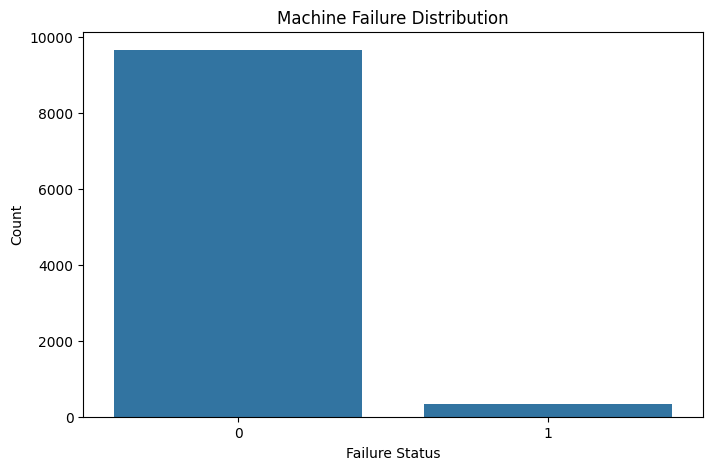

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(
    x="Machine failure",
    data=df
)
plt.title(
    "Machine Failure Distribution"
)

plt.xlabel("Failure Status")
plt.ylabel("Count")
plt.show()

In [13]:
failure_rate=(
    df["Machine failure"]
    .mean()
)*100

print("="*60)
print("Class Imbalance Report")
print("="*60)

print(f"Failure Rate:{failure_rate:.2f}%")

print(f"Healthy Rate:{100-failure_rate:.2f}%")

if failure_rate<10:
    print(
        "\nObservation:"
        "\nDataset is highly imbalanced."
    )
elif failure_rate<20:
    print({
        "\nObservation:"
        "\nModerately imbalanced dataset."
    }
         )

else:
    print(
        "\nObservation:"
        "\nClass distribution relatively balanced.")
    

Class Imbalance Report
Failure Rate:3.39%
Healthy Rate:96.61%

Observation:
Dataset is highly imbalanced.


In [14]:
failure_columns = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

failure_summary = pd.DataFrame({
    "Failure Type": failure_columns,
    "Count": [
        df[col].sum()
        for col in failure_columns
    ]
})

failure_summary["Percentage"] = (
    failure_summary["Count"]
    / len(df)
) * 100

failure_summary = failure_summary.sort_values(
    by="Count",
    ascending=False
)

display(failure_summary)

,Failure Type,Count,Percentage
1,HDF,115,1.15
3,OSF,98,0.98
2,PWF,95,0.95
0,TWF,46,0.46
4,RNF,19,0.19


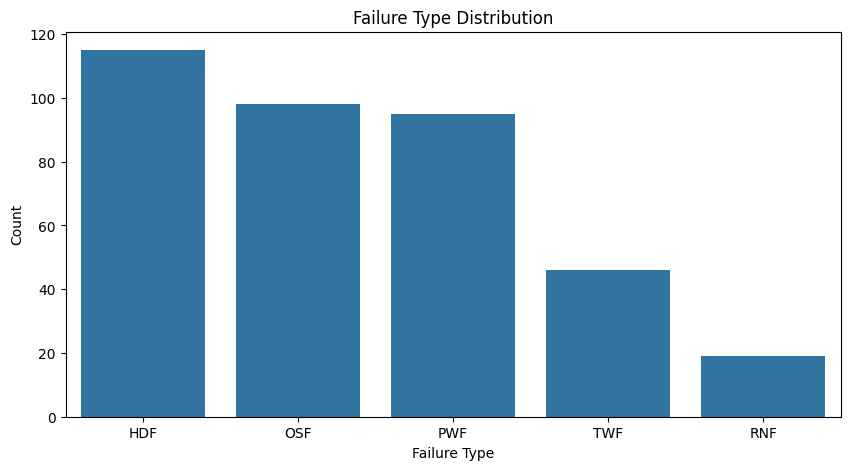

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=failure_summary,
    x="Failure Type",
    y="Count"
)
plt.title("Failure Type Distribution")
plt.show()

In [16]:
identifier_columns = [
    "UDI",
    "Product ID"
]

for column in identifier_columns:

    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)

    print(
        f"Unique Values : "
        f"{df[column].nunique():,}"
    )

    print(
        f"Duplicate Values : "
        f"{df[column].duplicated().sum():,}"
    )


UDI
Unique Values : 10,000
Duplicate Values : 0

Product ID
Unique Values : 10,000
Duplicate Values : 0


In [17]:
product_type_summary=(
    df.groupby("Type")
    ["Machine failure"].agg(
        Total_Records="count",
        Failure_Count="sum"
    )
)
product_type_summary["Failure_Rate"]=(
    product_type_summary["Failure_Count"]
    /
    product_type_summary["Total_Records"]
)*100
display(product_type_summary)

,Total_Records,Failure_Count,Failure_Rate
Type,,,
H,1003,21,2.093719
L,6000,235,3.916667
M,2997,83,2.769436


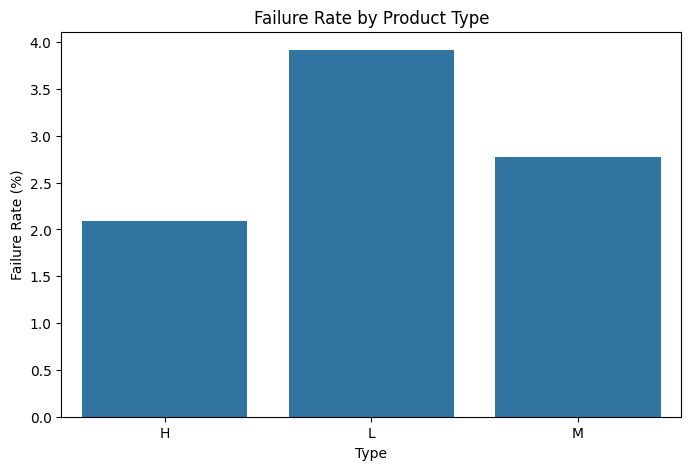

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=product_type_summary.index,
    y=product_type_summary["Failure_Rate"]
)
plt.title("Failure Rate by Product Type")
plt.ylabel("Failure Rate (%)")
plt.show()

In [19]:
numerical_columns = [

    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]

correlation_matrix = (
    df[numerical_columns]
    .corr()
)

display(
    correlation_matrix[
        ["Machine failure"]
    ].sort_values(
        by="Machine failure",
        ascending=False
    )
)

,Machine failure
Machine failure,1.000000
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Process temperature [K],0.035946
Rotational speed [rpm],-0.044188


In [20]:
ml_report={
    "rows":len(df),
    "features":len(df.columns)-1,
    "target":"Machine failure",
    "missing_values":int(df.isnull().sum().sum()),
    "duplicates":int(df.duplicated().sum()),
    "failure_rate_percent":
    round(failure_rate,2),
    "supports_binary_classification":True,
    "supports_multiclass_failure_analysis":True,
    "supports_anomaly_detection":True,
    "supports_clustering":True,
    "ready_for_feature_engineering":True
}
print(
    json.dumps(
        ml_report,
        indent=4
    )
)

{
    "rows": 10000,
    "features": 13,
    "target": "Machine failure",
    "missing_values": 0,
    "duplicates": 0,
    "failure_rate_percent": 3.39,
    "supports_binary_classification": true,
    "supports_multiclass_failure_analysis": true,
    "supports_anomaly_detection": true,
    "supports_clustering": true,
    "ready_for_feature_engineering": true
}


In [21]:
def build_engineered_features(dataframe):
    engineered_df = dataframe.copy()
    engineered_df["temperature_difference"] = (
        engineered_df["Process temperature [K]"]
        -
        engineered_df["Air temperature [K]"]
    )
    engineered_df["torque_speed_ratio"] = (
        engineered_df["Torque [Nm]"]
        /
        engineered_df["Rotational speed [rpm]"]
    )
    engineered_df["wear_intensity"] = (
        engineered_df["Tool wear [min]"]
        *
        engineered_df["Torque [Nm]"]
    )
    return engineered_df

In [22]:
df_engineered = build_engineered_features(df)
new_features = [
    "temperature_difference",
    "torque_speed_ratio",
    "wear_intensity"
]
display(
    df_engineered[
        new_features
    ].head()
)

,temperature_difference,torque_speed_ratio,wear_intensity
0,10.5,0.027595,0.0
1,10.5,0.032884,138.9
2,10.4,0.032977,247.0
3,10.4,0.027565,276.5
4,10.5,0.028409,360.0


In [23]:
df_engineered["machine_stress_index"] = (
    (
        df_engineered["temperature_difference"]
        /
        df_engineered["temperature_difference"].max()
    )
    +
    (
        df_engineered["Torque [Nm]"]
        /
        df_engineered["Torque [Nm]"].max()
    )
    +
    (
        df_engineered["Tool wear [min]"]
        /
        df_engineered["Tool wear [min]"].max()
    )
)
display(
    df_engineered[
        ["machine_stress_index"]
    ].head()
)

,machine_stress_index
0,1.426515
1,1.484065
2,1.524176
3,1.402838
4,1.425535


In [24]:
df_engineered["thermal_risk_index"] = (
    df_engineered["Process temperature [K]"]
    /
    df_engineered["Air temperature [K]"]
)
display(
    df_engineered[
        ["thermal_risk_index"]
    ].head()
)

,thermal_risk_index
0,1.035223
1,1.035211
2,1.034888
3,1.034876
4,1.035211


In [25]:
df_engineered["wear_efficiency_index"] = (
    df_engineered["Rotational speed [rpm]"]
    /
    (
        df_engineered["Tool wear [min]"] + 1
    )
)
display(
    df_engineered[
        ["wear_efficiency_index"]
    ].head()
)

,wear_efficiency_index
0,1551.000000
1,352.000000
2,249.666667
3,179.125000
4,140.800000


In [26]:
engineered_columns=[
    "temperature_difference",
    "torque_speed_ratio",
    "wear_intensity",
    "machine_stress_index",
    "thermal_risk_index",
    "wear_efficiency_index"
]
display(
    df_engineered[engineered_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
temperature_difference,10000.0,10.000630,1.001094,7.600000,9.300000,9.800000,11.000000,12.100000
torque_speed_ratio,10000.0,0.026895,0.008838,0.001317,0.020640,0.026735,0.032805,0.063833
wear_intensity,10000.0,4314.664550,2826.567692,0.000000,1963.650000,4012.950000,6279.000000,16497.000000
machine_stress_index,10000.0,1.775204,0.294457,0.870074,1.551314,1.775657,1.997428,2.673268
thermal_risk_index,10000.0,1.033352,0.003492,1.025116,1.030686,1.032847,1.036777,1.040672
wear_efficiency_index,10000.0,50.646142,174.355016,5.370213,9.403708,14.161364,28.366631,2232.000000


In [27]:
feature_correlation=(
    df_engineered[
    engineered_columns+["Machine failure"]
    ]
    .corr()
    [["Machine failure"]]
    .sort_values(
        by="Machine failure",
        ascending=False
    )
)
display(feature_correlation)

,Machine failure
Machine failure,1.000000
torque_speed_ratio,0.206493
wear_intensity,0.190427
machine_stress_index,0.143281
wear_efficiency_index,-0.014474
thermal_risk_index,-0.111347
temperature_difference,-0.111676


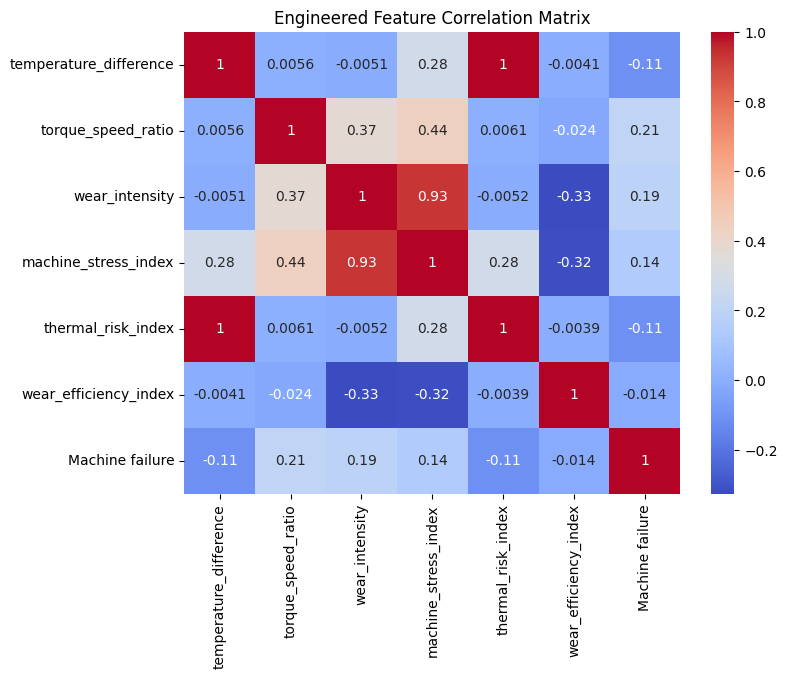

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df_engineered[engineered_columns+["Machine failure"]].corr(),
    annot=True,
    cmap="coolwarm"
    )
plt.title("Engineered Feature Correlation Matrix")
plt.show()

In [29]:
potential_leakage_columns=[
    "UDI","Product ID","TWF","HDF","PWF","OSF","RNF"
]
print(
    "Potential Leakage Columns"
)
for column in potential_leakage_columns:
    print(column)

Potential Leakage Columns
UDI
Product ID
TWF
HDF
PWF
OSF
RNF


In [30]:
modeling_df=df_engineered.copy()
columns_to_remove=[
    "UDI","Product ID","TWF","HDF","PWF","OSF","RNF"
]
modeling_df.drop(
    columns=columns_to_remove,
    inplace=True
)
print("="*60)
print("Modeling Dataset Ready")
print("="*60)
print(f"Rows:{modeling_df.shape[0]}")
print(f"Columns:{modeling_df.shape[1]}")
display(modeling_df.head())

Modeling Dataset Ready
Rows:10000
Columns:13


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index
0,M,298.1,308.6,1551,42.8,0,0,10.5,0.027595,0.0,1.426515,1.035223,1551.000000
1,L,298.2,308.7,1408,46.3,3,0,10.5,0.032884,138.9,1.484065,1.035211,352.000000
2,L,298.1,308.5,1498,49.4,5,0,10.4,0.032977,247.0,1.524176,1.034888,249.666667
3,L,298.2,308.6,1433,39.5,7,0,10.4,0.027565,276.5,1.402838,1.034876,179.125000
4,L,298.2,308.7,1408,40.0,9,0,10.5,0.028409,360.0,1.425535,1.035211,140.800000


In [31]:
#Feature Target Separation

TARGET_COLUMN="Machine failure"
X=modeling_df.drop(
    columns=[TARGET_COLUMN]
)
y=modeling_df[TARGET_COLUMN]
print("="*60)
print("Feature Matrix")
print("="*60)
print(f"X Shape:{X.shape}")
print(f"Y Shape:{y.shape}")
print("\nTarget Distribution")
display(
    y.value_counts()
)

Feature Matrix
X Shape:(10000, 12)
Y Shape:(10000,)

Target Distribution


Machine failure
0    9661
1     339
Name: count, dtype: int64

In [32]:
categorical_features=X.select_dtypes(
    include=["object"]).columns.tolist()
numerical_features=X.select_dtypes(
    include=np.number).columns.tolist()

print("="*60)
print("Categorical Features")
print("="*60)

print(categorical_features)
print("\n")

print("="*60)
print("Numerical Features")
print("="*60)
print(numerical_features)

Categorical Features
['Type']


Numerical Features
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temperature_difference', 'torque_speed_ratio', 'wear_intensity', 'machine_stress_index', 'thermal_risk_index', 'wear_efficiency_index']


In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)

print("="*60)
print("Dataset Split Complete")
print("="*60)

print(f"Train Shape:{X_train.shape}")
print(f"Test Shape:{X_test.shape}")
print("\nTrain Distribution")
display(y_train.value_counts())
print("\nTest Distribution")
display(y_test.value_counts())

Dataset Split Complete
Train Shape:(8000, 12)
Test Shape:(2000, 12)

Train Distribution


Machine failure
0    7729
1     271
Name: count, dtype: int64


Test Distribution


Machine failure
0    1932
1      68
Name: count, dtype: int64

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler,OneHotEncoder)
numeric_transformer=StandardScaler()
categorical_transformer=OneHotEncoder(handle_unknown="ignore")
preprocessor=ColumnTransformer(
    transformers=[
        ("numerical",numeric_transformer,numerical_features),
        ("categorical",categorical_transformer,categorical_features)
    ]
)
preprocessor

ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]', 'temperature_difference',
                                  'torque_speed_ratio', 'wear_intensity',
                                  'machine_stress_index', 'thermal_risk_index',
                                  'wear_efficiency_index']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Type'])])

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_pipeline=Pipeline(
    steps=[
    ("preprocessing",preprocessor),
    ("classifier",LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
    )
    ]
)
baseline_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'temperature_difference',
                                                   'torque_speed_ratio',
                                                   'wear_intensity',
                                                   'machine_stress_index',
                                                   'thermal_risk_index',
                                                   'wear_efficiency_index']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    random_state=42))])

In [36]:
baseline_pipeline.fit(X_train,y_train)
print("Baseline Pipeline Successfully Trained")

Baseline Pipeline Successfully Trained


In [37]:
y_pred=baseline_pipeline.predict(X_test)
y_proba=baseline_pipeline.predict_proba(X_test)[:,1]
print(f"Predictions Generated:{len(y_pred)}")

Predictions Generated:2000


In [38]:
from sklearn.metrics import(
accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
evaluation_results={
    "Accuracy":accuracy_score(y_test,y_pred),
    "Precision":precision_score(y_test,y_pred),
    "Recall":recall_score(y_test,y_pred),
    "F1 Score":f1_score(y_test,y_pred),
    "ROC AUC":roc_auc_score(y_test,y_proba)
}
pd.DataFrame(evaluation_results.items(),
             columns=["Metric","Score"]
            )

,Metric,Score
0,Accuracy,0.856000
1,Precision,0.176471
2,Recall,0.882353
3,F1 Score,0.294118
4,ROC AUC,0.937553


In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1932
           1       0.18      0.88      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000



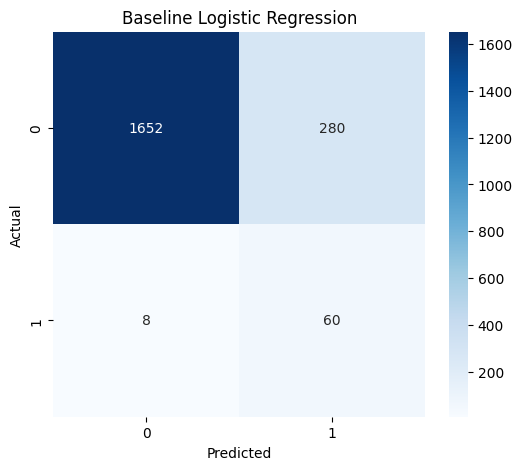

In [40]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,y_pred
)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,annot=True,fmt="d",cmap="Blues"
)
plt.title(
    "Baseline Logistic Regression"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
from sklearn.model_selection import cross_validate
scoring_metrics={
    "accuracy":"accuracy",
    "precision":"precision",
    "recall":"recall",
    "f1":"f1",
    "roc_auc":"roc_auc"
}
baseline_cv_results=cross_validate(
    baseline_pipeline,X_train,y_train,cv=5,scoring=scoring_metrics,
    n_jobs=-1,return_train_score=False
)
cv_summary=pd.DataFrame({
    metric:
    baseline_cv_results[f"test_{metric}"]
    for metric in scoring_metrics
})
display(cv_summary)

,accuracy,precision,recall,f1,roc_auc
0,0.856250,0.169173,0.833333,0.281250,0.932801
1,0.842500,0.163265,0.888889,0.275862,0.938898
2,0.836250,0.151007,0.833333,0.255682,0.909803
3,0.856875,0.174721,0.870370,0.291022,0.931017
4,0.853750,0.162264,0.781818,0.268750,0.909573


In [42]:
cv_statistics=pd.DataFrame({
    "Mean":cv_summary.mean(),
    "Std":cv_summary.std()
})
display(cv_statistics)

,Mean,Std
accuracy,0.849125,0.009245
precision,0.164086,0.008861
recall,0.841549,0.041154
f1,0.274513,0.013300
roc_auc,0.924419,0.013761


In [43]:
from sklearn.ensemble import RandomForestClassifier
rf_pipeline=Pipeline(
    steps=[
        ("preprocessing",preprocessor),
        ("classifier",
         RandomForestClassifier(
             n_estimators=300,
             max_depth=10,
             min_samples_split=5,
             class_weight="balanced",
             random_state=RANDOM_STATE,
             n_jobs=-1
         )
        )
    ]
)
rf_pipeline                                  

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'temperature_difference',
                                                   'torque_speed_ratio',
                                                   'wear_intensity',
                                                   'machine_stress_index',
                                                   'thermal_risk_index',
                                                   'wear_efficiency_index']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_split=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [44]:
rf_pipeline.fit(
    X_train,y_train)
print("Random Forest Training Complete")

Random Forest Training Complete


In [45]:
rf_predictions=rf_pipeline.predict(
    X_test)
rf_probabilities=rf_pipeline.predict_proba(
    X_test)[:,1]
print(f"Prediction Generated:{len(rf_predictions)}")

Prediction Generated:2000


In [46]:
rf_metrics={
    "Accuracy":accuracy_score(y_test,rf_predictions),
    "Precision":precision_score(y_test,rf_predictions),
    "Recall":recall_score(y_test,rf_predictions),
    "F1":f1_score(y_test,rf_predictions),
    "ROC AUC":roc_auc_score(y_test,rf_probabilities)
}
pd.DataFrame(rf_metrics.items(),
             columns=["Metric","Score"]
            )

,Metric,Score
0,Accuracy,0.990000
1,Precision,0.913793
2,Recall,0.779412
3,F1,0.841270
4,ROC AUC,0.983437


In [47]:
print(classification_report(y_test,rf_predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.91      0.78      0.84        68

    accuracy                           0.99      2000
   macro avg       0.95      0.89      0.92      2000
weighted avg       0.99      0.99      0.99      2000



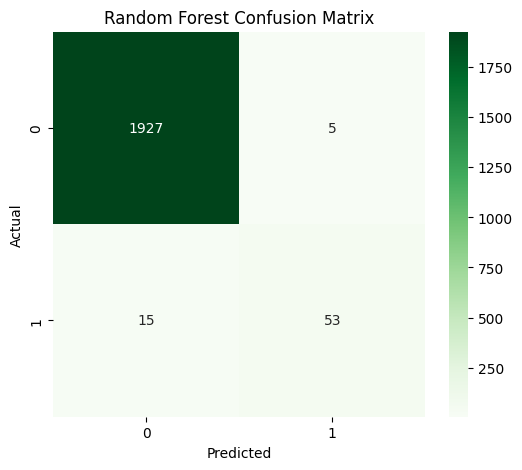

In [48]:
rf_cm=confusion_matrix(
    y_test,rf_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm,annot=True,fmt="d",cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
comparison_df=pd.DataFrame({
    "Metric":list(evaluation_results.keys()),
    "Logistic Regression":list(evaluation_results.values()),
    "Random Forest":list(rf_metrics.values())
})
display(comparison_df)

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.856000,0.990000
1,Precision,0.176471,0.913793
2,Recall,0.882353,0.779412
3,F1 Score,0.294118,0.841270
4,ROC AUC,0.937553,0.983437


In [50]:
comparison_df["Difference"]=(
    comparison_df["Random Forest"]
    -
    comparison_df["Logistic Regression"]
)
display(comparison_df)
print("="*60)
print("Baseline Modeling Complete")
print("="*60)

,Metric,Logistic Regression,Random Forest,Difference
0,Accuracy,0.856000,0.990000,0.134000
1,Precision,0.176471,0.913793,0.737323
2,Recall,0.882353,0.779412,-0.102941
3,F1 Score,0.294118,0.841270,0.547152
4,ROC AUC,0.937553,0.983437,0.045884


Baseline Modeling Complete


In [51]:
try:
    import xgboost
    print(f"XGBoost Version:{xgboost.__version__}")
except Exception as e:
    print("Install XGBoost First")
    print(e)

XGBoost Version:3.2.0


In [52]:
from xgboost import XGBClassifier
xgb_pipeline=Pipeline(
    steps=[
        ("preprocessing",preprocessor),
        ("classifier",XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=10,
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        )
        )
    ]
)
xgb_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'temperature_difference',
                                                   'torque_speed_ratio',
                                                   'wear_intensity',
                                                   'machine_stress_index',
                                                   'thermal_risk_index',
                                                   'wear_efficiency_index']),
                                                 ('categorical',
                                                  OneHotEnco...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [53]:
xgb_pipeline.fit(X_train,y_train)
print("XGBoost Training Complete")

XGBoost Training Complete


In [54]:
xgb_predictions=xgb_pipeline.predict(X_test)
xgb_probabilities=(xgb_pipeline.predict_proba(X_test))[:,1]
print(f"Predictions Generated:{len(xgb_predictions)}"
     )

Predictions Generated:2000


In [55]:
xgb_metrics={
    "Accuracy":accuracy_score(y_test,xgb_predictions),
    "Precision":precision_score(y_test,xgb_predictions),
    "Recall":recall_score(y_test,xgb_predictions),
    "F1":f1_score(y_test,xgb_predictions),
    "ROC AUC":roc_auc_score(y_test,xgb_probabilities)
}
pd.DataFrame(
    xgb_metrics.items(),
    columns=["Metric","Score"]
)

,Metric,Score
0,Accuracy,0.989500
1,Precision,0.873016
2,Recall,0.808824
3,F1,0.839695
4,ROC AUC,0.981313


In [56]:
print(classification_report(y_test,xgb_predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.87      0.81      0.84        68

    accuracy                           0.99      2000
   macro avg       0.93      0.90      0.92      2000
weighted avg       0.99      0.99      0.99      2000



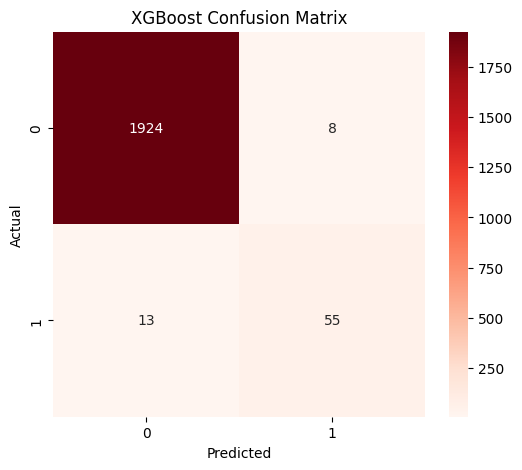

In [57]:
xgb_cm=confusion_matrix(
    y_test,
    xgb_predictions
)
plt.figure(figsize=(6,5))
sns.heatmap(xgb_cm,annot=True,fmt="d",cmap="Reds")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
leaderboard=pd.DataFrame({
    "Metric":list(evaluation_results.keys()),
    "Logistic Regression":list(evaluation_results.values()),
    "Random Forest":list(rf_metrics.values()),
    "XGBoost":list(xgb_metrics.values())
})
display(leaderboard)

,Metric,Logistic Regression,Random Forest,XGBoost
0,Accuracy,0.856000,0.990000,0.989500
1,Precision,0.176471,0.913793,0.873016
2,Recall,0.882353,0.779412,0.808824
3,F1 Score,0.294118,0.841270,0.839695
4,ROC AUC,0.937553,0.983437,0.981313


In [59]:
leaderboard.set_index(
    "Metric",
    inplace=True)
display(leaderboard)
print("="*60)
print("Current Leader Based On ROC-AUC")
print("="*60)
print(leaderboard.loc["ROC AUC"].sort_values(ascending=False))

,Logistic Regression,Random Forest,XGBoost
Metric,,,
Accuracy,0.856000,0.990000,0.989500
Precision,0.176471,0.913793,0.873016
Recall,0.882353,0.779412,0.808824
F1 Score,0.294118,0.841270,0.839695
ROC AUC,0.937553,0.983437,0.981313


Current Leader Based On ROC-AUC
Random Forest          0.983437
XGBoost                0.981313
Logistic Regression    0.937553
Name: ROC AUC, dtype: float64


In [60]:
try:
    import optuna
    print(f"Optuna Version:{optuna.__version__}")
except Exception as e:
    print("Run:pip install optuna")
    print(e)

Optuna Version:4.9.0


In [61]:
X_train_opt,X_valid_opt,y_train_opt,y_valid_opt=train_test_split(
    X_train,y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE
)
print(X_train_opt.shape,
      X_valid_opt.shape
     )

(6400, 12) (1600, 12)


In [62]:
# ============================================================
# XGBoost Optimization Objective
# ============================================================

from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

def objective(trial):

    n_estimators = trial.suggest_int(
        "n_estimators",
        100,
        500
    )

    max_depth = trial.suggest_int(
        "max_depth",
        3,
        10
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        0.01,
        0.3
    )

    subsample = trial.suggest_float(
        "subsample",
        0.6,
        1.0
    )

    colsample_bytree = trial.suggest_float(
        "colsample_bytree",
        0.6,
        1.0
    )

    scale_pos_weight = trial.suggest_int(
        "scale_pos_weight",
        1,
        20
    )

    model = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),
            (
                "classifier",
                XGBClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    learning_rate=learning_rate,
                    subsample=subsample,
                    colsample_bytree=colsample_bytree,
                    scale_pos_weight=scale_pos_weight,
                    random_state=RANDOM_STATE,
                    eval_metric="logloss"
                )
            )
        ]
    )

    model.fit(
        X_train_opt,
        y_train_opt
    )

    probabilities = (
        model.predict_proba(
            X_valid_opt
        )[:, 1]
    )

    score = roc_auc_score(
        y_valid_opt,
        probabilities
    )

    return score

In [63]:
study=optuna.create_study(
    direction="maximize"
)
study.optimize(objective,n_trials=25,show_progress_bar=True)
print(study.best_value)

[I 2026-07-13 10:56:16,577] A new study created in memory with name: no-name-8893aee4-5207-40c2-b408-4a4175dc035c


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-07-13 10:56:16,855] Trial 0 finished with value: 0.9534162234679698 and parameters: {'n_estimators': 259, 'max_depth': 10, 'learning_rate': 0.23167535397703165, 'subsample': 0.8074156475760195, 'colsample_bytree': 0.7377925592261454, 'scale_pos_weight': 8}. Best is trial 0 with value: 0.9534162234679698.
[I 2026-07-13 10:56:17,500] Trial 1 finished with value: 0.9689161995112838 and parameters: {'n_estimators': 437, 'max_depth': 8, 'learning_rate': 0.021435636094264507, 'subsample': 0.6658556677002703, 'colsample_bytree': 0.9129970602952607, 'scale_pos_weight': 5}. Best is trial 1 with value: 0.9689161995112838.
[I 2026-07-13 10:56:17,619] Trial 2 finished with value: 0.9644722342005654 and parameters: {'n_estimators': 163, 'max_depth': 3, 'learning_rate': 0.11504293651180658, 'subsample': 0.8122459394404555, 'colsample_bytree': 0.656761202034171, 'scale_pos_weight': 20}. Best is trial 1 with value: 0.9689161995112838.
[I 2026-07-13 10:56:17,908] Trial 3 finished with value: 0.

In [64]:
print("="*60)
print("Best ROC-AUC")
print("="*60)
print(
    study.best_value
)
print("\n")
print("="*60)
print("Best Parameters")
print("="*60)
print(
    study.best_params
)

Best ROC-AUC
0.9794571414881894


Best Parameters
{'n_estimators': 273, 'max_depth': 10, 'learning_rate': 0.010806039513837842, 'subsample': 0.6419184863263582, 'colsample_bytree': 0.6374185064642379, 'scale_pos_weight': 3}


In [65]:
optimized_xgb=Pipeline(
    steps=[
        ("preprocessing",preprocessor),
        ("classifier",XGBClassifier(**study.best_params,random_state=RANDOM_STATE,eval_metric="logloss")
        )
    ]
)
optimized_xgb.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'temperature_difference',
                                                   'torque_speed_ratio',
                                                   'wear_intensity',
                                                   'machine_stress_index',
                                                   'thermal_risk_index',
                                                   'wear_efficiency_index']),
                                                 ('categorical',
                                                  OneHotEnco...
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.010806039513837842, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=10,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=273,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [66]:
opt_predictions = (
    optimized_xgb
    .predict(X_test)
)
opt_probabilities = (
    optimized_xgb
    .predict_proba(X_test)
)[:,1]

In [67]:
optimized_metrics = {
    "Accuracy":
        accuracy_score(
            y_test,
            opt_predictions
        ),
    "Precision":
        precision_score(
            y_test,
            opt_predictions
        ),
    "Recall":
        recall_score(
            y_test,
            opt_predictions
        ),
    "F1":
        f1_score(
            y_test,
            opt_predictions
        ),
    "ROC AUC":
        roc_auc_score(
            y_test,
            opt_probabilities
        )
}
pd.DataFrame(
    optimized_metrics.items(),
    columns=["Metric","Score"]
)

,Metric,Score
0,Accuracy,0.990000
1,Precision,0.900000
2,Recall,0.794118
3,F1,0.843750
4,ROC AUC,0.981161


In [68]:
final_leaderboard = pd.DataFrame({
    "Metric":
        list(evaluation_results.keys()),
    "Logistic":
        list(evaluation_results.values()),
    "RandomForest":
        list(rf_metrics.values()),
    "XGBoost":
        list(xgb_metrics.values()),
    "OptimizedXGB":
        list(optimized_metrics.values())
})
display(
    final_leaderboard
)

,Metric,Logistic,RandomForest,XGBoost,OptimizedXGB
0,Accuracy,0.856000,0.990000,0.989500,0.990000
1,Precision,0.176471,0.913793,0.873016,0.900000
2,Recall,0.882353,0.779412,0.808824,0.794118
3,F1 Score,0.294118,0.841270,0.839695,0.843750
4,ROC AUC,0.937553,0.983437,0.981313,0.981161


In [69]:
import joblib
MODEL_VERSION="v1.0.0"
MODEL_NAME="ManufacturingIQ_XBoost"
MODEL_PATH=(
    MODEL_DIR/f"{MODEL_NAME}_{MODEL_VERSION}.joblib"
)
print(MODEL_PATH)

/kaggle/working/models/ManufacturingIQ_XBoost_v1.0.0.joblib


In [70]:
joblib.dump(
    optimized_xgb,
    MODEL_PATH)

print("="*60)
print("Model Saved Successfully")
print("="*60)
print(MODEL_PATH)

Model Saved Successfully
/kaggle/working/models/ManufacturingIQ_XBoost_v1.0.0.joblib


In [71]:
loaded_model=joblib.load(MODEL_PATH)
print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [72]:
model_metadata={
    "model_name":MODEL_NAME,
    "version":MODEL_VERSION,
    "algorithm":"Optimized XGBoost",
    "roc_auc":optimized_metrics["ROC AUC"],
    "precision":optimized_metrics["Precision"],
    "recall":optimized_metrics["Recall"],
    "f1_score":optimized_metrics["F1"],
    "training_rows":len(X_train),
    "feature_count":X.shape[1]
}
model_metadata

{'model_name': 'ManufacturingIQ_XBoost',
 'version': 'v1.0.0',
 'algorithm': 'Optimized XGBoost',
 'roc_auc': np.float64(0.9811609426379247),
 'precision': 0.9,
 'recall': 0.7941176470588235,
 'f1_score': 0.84375,
 'training_rows': 8000,
 'feature_count': 12}

In [73]:
registry_path=(
    ARTIFACT_DIR/"model_registry.json"
)
with open(registry_path,"w")as file:
    json.dump(model_metadata,file,indent=4)
print(registry_path)

/kaggle/working/artifacts/model_registry.json


In [74]:
sample_machine = {
    "Type": "M",
    "Air temperature [K]": 298.1,
    "Process temperature [K]": 308.6,
    "Rotational speed [rpm]": 1551,
    "Torque [Nm]": 42.8,
    "Tool wear [min]": 12
}
sample_machine

{'Type': 'M',
 'Air temperature [K]': 298.1,
 'Process temperature [K]': 308.6,
 'Rotational speed [rpm]': 1551,
 'Torque [Nm]': 42.8,
 'Tool wear [min]': 12}

In [75]:
def build_inference_features(data):
    dataframe=pd.DataFrame([data])
    dataframe["temperature_difference"]=(
    dataframe["Process temperature [K]"]
    -
    dataframe["Air temperature [K]"]
    )
    dataframe["torque_speed_ratio"]=(
    dataframe["Torque [Nm]"]
    /
    dataframe["Rotational speed [rpm]"]
    )
    dataframe["wear_intensity"]=(
    dataframe["Tool wear [min]"]
    *
    dataframe["Torque [Nm]"]
    )
    dataframe["machine_stress_index"]=(
    (
    dataframe["temperature_difference"]/100
    )
    +
    (
    dataframe["Torque [Nm]"]/100
    )
    +
    (
    dataframe["Tool wear [min]"]/100
    )
    )
    dataframe["thermal_risk_index"]=(
    dataframe["Process temperature [K]"]
    /
    dataframe["Air temperature [K]"]
    )
    dataframe["wear_efficiency_index"]=(
    dataframe["Rotational speed [rpm]"]
    /
    (dataframe["Tool wear [min]"]+1
    )
    )
    return dataframe

In [76]:
def predict_failure(machine_data):
    features=build_inference_features(
        machine_data
    )
    probability=(
    loaded_model.predict_proba(features)
    )[:,1][0]
    prediction=(
    loaded_model.predict(features)
    )[0]

    return {
        "failure_prediction":
        int(prediction),
        "failure_probability":
            round(probability,4)
    }

In [77]:
prediction_output = predict_failure(
    sample_machine
)

prediction_output

{'failure_prediction': 0, 'failure_probability': np.float32(0.0108)}

In [78]:
print("="*70)

print(
    "MANUFACTURINGIQ MODEL REGISTRY"
)

print("="*70)

for key, value in model_metadata.items():

    print(
        f"{key:<20} : {value}"
    )

MANUFACTURINGIQ MODEL REGISTRY
model_name           : ManufacturingIQ_XBoost
version              : v1.0.0
algorithm            : Optimized XGBoost
roc_auc              : 0.9811609426379247
precision            : 0.9
recall               : 0.7941176470588235
f1_score             : 0.84375
training_rows        : 8000
feature_count        : 12


In [79]:
def classify_risk(probability):
    if probability<0.20:
        return "Low"
    elif probability<0.50:
        return "Moderate"
    elif probability<0.80:
        return "High"
    return "Critical"

In [80]:
def calculate_health_score(probability):
    health_score=int((1-probability)*100
    )
    return max(0,min(100,health_score)
              )

In [81]:
def maintenance_recommendation(probability):
    if probability<0.20:
        return "Monitor"
    elif probability<0.50:
        return "Schedule Inspection"
    elif probability<0.80:
        return "Preventive Maintenance"
    return "Immediate Maintenance"

In [82]:
def identify_risk_driver(machine_data):
    features={
        "Tool Wear":machine_data["Tool wear [min]"],
        "Torque":machine_data["Torque [Nm]"],
        "Temperature Difference":(
            machine_data["Process temperature [K]"]
            -
            machine_data["Air temperature [K]"]
        )
    }
    return max(features,key=features.get)

In [83]:
def predict_machine_intelligence(
    machine_data
):

    features = build_inference_features(
        machine_data
    )

    probability = (

        loaded_model

        .predict_proba(features)

    )[:,1][0]

    prediction = (

        loaded_model

        .predict(features)

    )[0]

    return {

        "failure_prediction":
            int(prediction),

        "failure_probability":
            round(
                float(probability),
                4
            ),

        "risk_level":
            classify_risk(
                probability
            ),

        "health_score":
            calculate_health_score(
                probability
            ),

        "maintenance_action":
            maintenance_recommendation(
                probability
            ),

        "primary_risk_driver":
            identify_risk_driver(
                machine_data
            )
    }

In [84]:
machine_report = (

    predict_machine_intelligence(
        sample_machine
    )
)

machine_report

{'failure_prediction': 0,
 'failure_probability': 0.0108,
 'risk_level': 'Low',
 'health_score': 98,
 'maintenance_action': 'Monitor',
 'primary_risk_driver': 'Torque'}

In [85]:
high_risk_machine = {

    "Type":"H",

    "Air temperature [K]":298,

    "Process temperature [K]":320,

    "Rotational speed [rpm]":1100,

    "Torque [Nm]":75,

    "Tool wear [min]":250
}

high_risk_machine

{'Type': 'H',
 'Air temperature [K]': 298,
 'Process temperature [K]': 320,
 'Rotational speed [rpm]': 1100,
 'Torque [Nm]': 75,
 'Tool wear [min]': 250}

In [86]:
predict_machine_intelligence(
    high_risk_machine
)

{'failure_prediction': 1,
 'failure_probability': 0.8108,
 'risk_level': 'Critical',
 'health_score': 18,
 'maintenance_action': 'Immediate Maintenance',
 'primary_risk_driver': 'Tool Wear'}

In [87]:
factory_machines = [

    sample_machine,

    high_risk_machine
]

factory_reports = []

for machine in factory_machines:

    factory_reports.append(

        predict_machine_intelligence(
            machine
        )
    )

factory_df = pd.DataFrame(
    factory_reports
)

factory_df

,failure_prediction,failure_probability,risk_level,health_score,maintenance_action,primary_risk_driver
0,0,0.0108,Low,98,Monitor,Torque
1,1,0.8108,Critical,18,Immediate Maintenance,Tool Wear


In [88]:
print("="*70)

print(
    "MANUFACTURINGIQ FACTORY REPORT"
)

print("="*70)

print(
    f"Machines Analysed : {len(factory_df)}"
)

print(
    f"Average Health Score : "
    f"{factory_df['health_score'].mean():.2f}"
)

print(
    f"Critical Machines : "
    f"{(factory_df['risk_level']=='Critical').sum()}"
)

print(
    f"High Risk Machines : "
    f"{(factory_df['risk_level']=='High').sum()}"
)

MANUFACTURINGIQ FACTORY REPORT
Machines Analysed : 2
Average Health Score : 58.00
Critical Machines : 1
High Risk Machines : 0


In [89]:
import shap
print(f"SHAP Version:{shap.__version__}"
     )

SHAP Version:0.51.0


In [90]:
xgb_model = (
    optimized_xgb.named_steps[
        "classifier"
    ]
)
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6374185064642379, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.010806039513837842,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=273, n_jobs=None,
              num_parallel_tree=None, ...)

In [91]:
X_train_transformed = (
    preprocessor
    .fit_transform(
        X_train
    )
)
X_test_transformed = (
    preprocessor
    .transform(
        X_test
    )
)
print(
    X_train_transformed.shape
)

(8000, 14)


In [92]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)
feature_names[:20]

array(['numerical__Air temperature [K]',
       'numerical__Process temperature [K]',
       'numerical__Rotational speed [rpm]', 'numerical__Torque [Nm]',
       'numerical__Tool wear [min]', 'numerical__temperature_difference',
       'numerical__torque_speed_ratio', 'numerical__wear_intensity',
       'numerical__machine_stress_index', 'numerical__thermal_risk_index',
       'numerical__wear_efficiency_index', 'categorical__Type_H',
       'categorical__Type_L', 'categorical__Type_M'], dtype=object)

In [93]:
explainer = shap.TreeExplainer(
    xgb_model
)
explainer

In [94]:
sample_size = 500
shap_values = explainer.shap_values(
    X_test_transformed[:sample_size]
)
print(
    np.array(shap_values).shape
)

(500, 14)


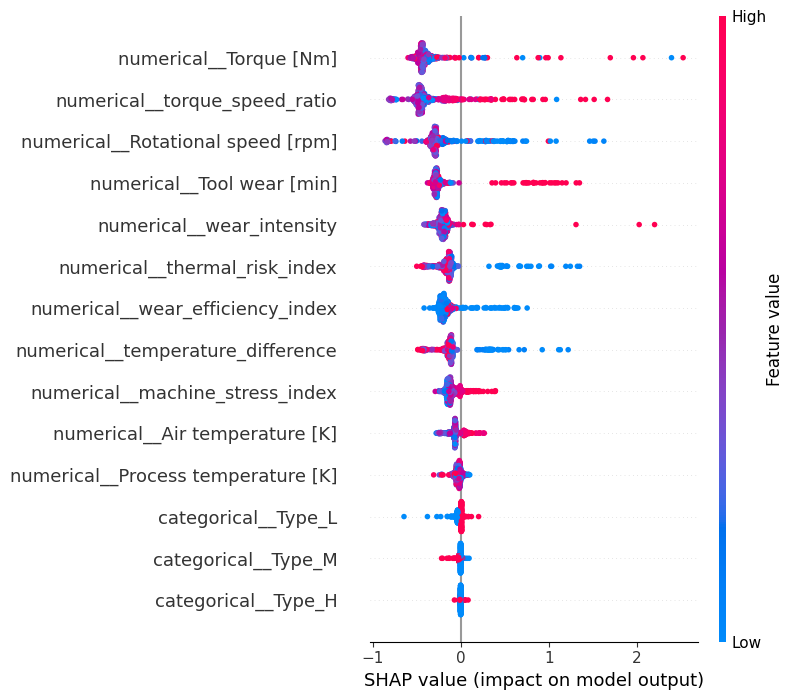

In [95]:
shap.summary_plot(
    shap_values,
    X_test_transformed[:sample_size],
    feature_names=feature_names
)

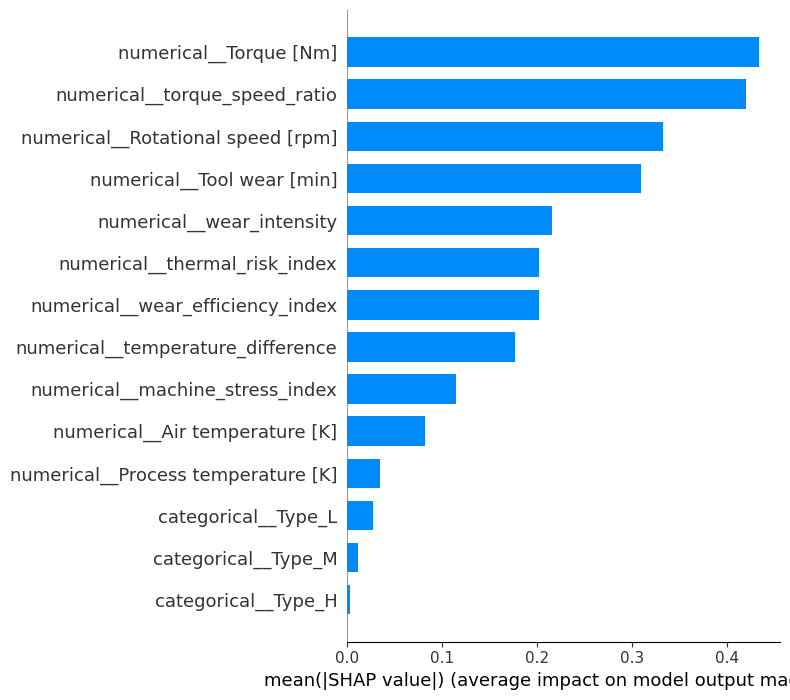

In [96]:
shap.summary_plot(
    shap_values,
    X_test_transformed[:sample_size],
    feature_names=feature_names,
    plot_type="bar"
)

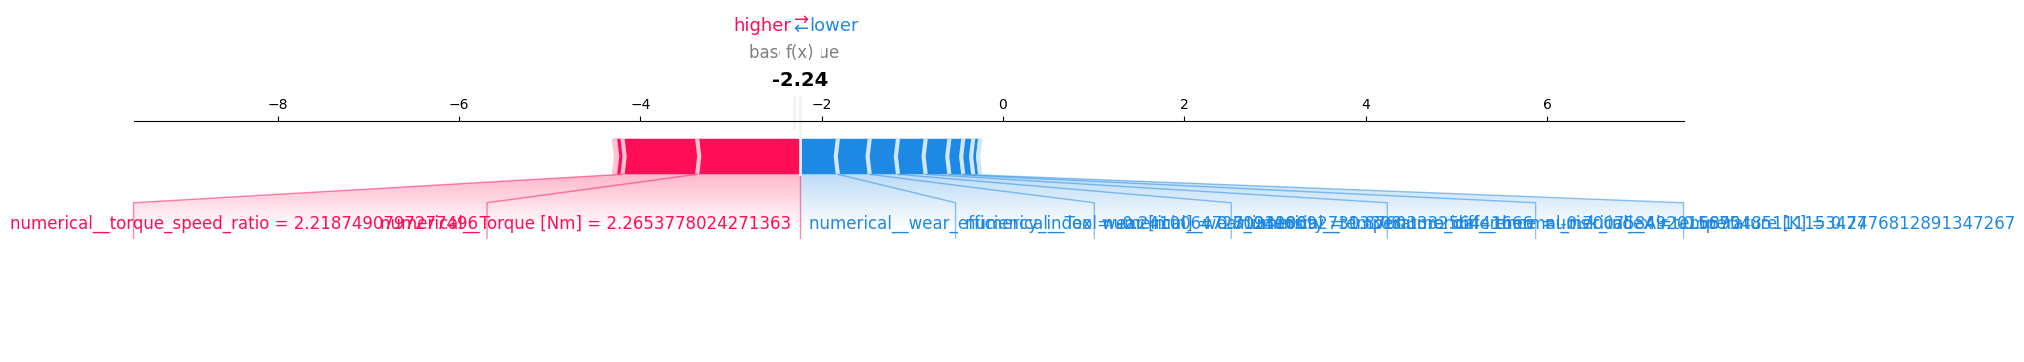

In [97]:
machine_index = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[machine_index],
    X_test_transformed[machine_index],
    feature_names=feature_names,
    matplotlib=True
)

In [98]:
machine_index = 0
contributions = pd.DataFrame({
    "Feature":
        feature_names,
    "SHAP_Contribution":
        shap_values[machine_index]
})

contributions["Absolute_Impact"] = (
    contributions[
        "SHAP_Contribution"
    ].abs()
)

top_risk_drivers = (
    contributions
    .sort_values(
        "Absolute_Impact",
        ascending=False
    )
    .head(10)
)
display(
    top_risk_drivers
)

,Feature,SHAP_Contribution,Absolute_Impact
3,numerical__Torque [Nm],1.136560,1.136560
6,numerical__torque_speed_ratio,0.822886,0.822886
10,numerical__wear_efficiency_index,-0.415204,0.415204
4,numerical__Tool wear [min],-0.351430,0.351430
7,numerical__wear_intensity,-0.311667,0.311667
5,numerical__temperature_difference,-0.305533,0.305533
9,numerical__thermal_risk_index,-0.260994,0.260994
0,numerical__Air temperature [K],-0.153371,0.153371
8,numerical__machine_stress_index,-0.109716,0.109716
2,numerical__Rotational speed [rpm],0.082171,0.082171


In [99]:
anomaly_features = [

    "Air temperature [K]","Process temperature [K]","Rotational speed [rpm]","Torque [Nm]","Tool wear [min]",
    "temperature_difference","torque_speed_ratio","wear_intensity","machine_stress_index",
    "thermal_risk_index","wear_efficiency_index"
]

anomaly_df = df_engineered[
    anomaly_features
].copy()

print(anomaly_df.shape)

(10000, 11)


In [100]:
from sklearn.preprocessing import StandardScaler
anomaly_scaler = StandardScaler()
anomaly_scaled = anomaly_scaler.fit_transform(
    anomaly_df
)
print(anomaly_scaled.shape)

(10000, 11)


In [101]:
from sklearn.ensemble import IsolationForest
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=RANDOM_STATE
)

isolation_forest.fit(
    anomaly_scaled
)
print(
    "Isolation Forest Trained"
)

Isolation Forest Trained


In [102]:
df_engineered["anomaly_score"] = (
    isolation_forest.score_samples(
        anomaly_scaled
    )
)

df_engineered["anomaly_flag"] = (
    isolation_forest.predict(
        anomaly_scaled
    )
)

df_engineered.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index,anomaly_score,anomaly_flag
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,0.027595,0.0,1.426515,1.035223,1551.000000,-0.565983,1
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,0.032884,138.9,1.484065,1.035211,352.000000,-0.506972,1
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,0.032977,247.0,1.524176,1.034888,249.666667,-0.499686,1
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,0.027565,276.5,1.402838,1.034876,179.125000,-0.471606,1
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,0.028409,360.0,1.425535,1.035211,140.800000,-0.465483,1


In [103]:
df_engineered[
    "anomaly_flag"
].value_counts()

anomaly_flag
 1    9700
-1     300
Name: count, dtype: int64

In [104]:
anomaly_percentage = (

    (
        df_engineered[
            "anomaly_flag"
        ] == -1
    ).mean()
) * 100

print(
    f"Anomalies : {anomaly_percentage:.2f}%"
)

Anomalies : 3.00%


In [105]:
comparison_table = pd.crosstab(

    df_engineered[
        "Machine failure"
    ],

    df_engineered[
        "anomaly_flag"
    ]
)

display(
    comparison_table
)

anomaly_flag,-1,1
Machine failure,,
0,210,9451
1,90,249


In [106]:
top_anomalies = (
    df_engineered
    .sort_values(
        by="anomaly_score"
    )
    .head(20)
)

display(
    top_anomalies[
        [
            "Type","Machine failure","anomaly_score"
        ]
    ]
)

,Type,Machine failure,anomaly_score
4903,L,0,-0.684250
418,L,0,-0.668860
3867,M,1,-0.668524
4647,L,0,-0.664997
4988,L,1,-0.661631
8114,H,0,-0.659910
4302,L,0,-0.658269
5152,L,0,-0.655776
4419,M,1,-0.655746
1095,L,1,-0.652816


In [107]:
anomaly_comparison = (
    df_engineered
    .groupby(
        "anomaly_flag"
    )
    [anomaly_features].mean()
)
display(
    anomaly_comparison
)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index
anomaly_flag,,,,,,,,,,,
-1,300.456667,310.244667,1814.556667,35.037,74.306667,9.788000,0.023559,2850.254000,1.560030,1.032602,540.093780
1,299.990959,309.998165,1530.246804,40.140,108.991546,10.007206,0.026998,4359.955598,1.781859,1.033375,35.508586


In [108]:
print("="*70)
print(
    "MANUFACTURINGIQ ANOMALY REPORT"
)
print("="*70)
print(
    f"Total Machines : {len(df_engineered)}"
)
print(
    f"Anomalies : "
    f"{(df_engineered['anomaly_flag']==-1).sum()}"
)
print(
    f"Actual Failures : "
    f"{df_engineered['Machine failure'].sum()}"
)

MANUFACTURINGIQ ANOMALY REPORT
Total Machines : 10000
Anomalies : 300
Actual Failures : 339


In [109]:
cluster_features = [
    "Air temperature [K]","Process temperature [K]","Rotational speed [rpm]",
    "Torque [Nm]","Tool wear [min]","temperature_difference",
    "torque_speed_ratio","wear_intensity","machine_stress_index",
    "thermal_risk_index","wear_efficiency_index","anomaly_score"
]

cluster_df = df_engineered[
    cluster_features
].copy()

cluster_df.shape

(10000, 12)

In [110]:
cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_df
)

print(cluster_scaled.shape)

(10000, 12)


In [111]:
from sklearn.cluster import KMeans
inertia_values = []
k_values = range(2,11)
for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    model.fit(cluster_scaled)

    inertia_values.append(
        model.inertia_
    )

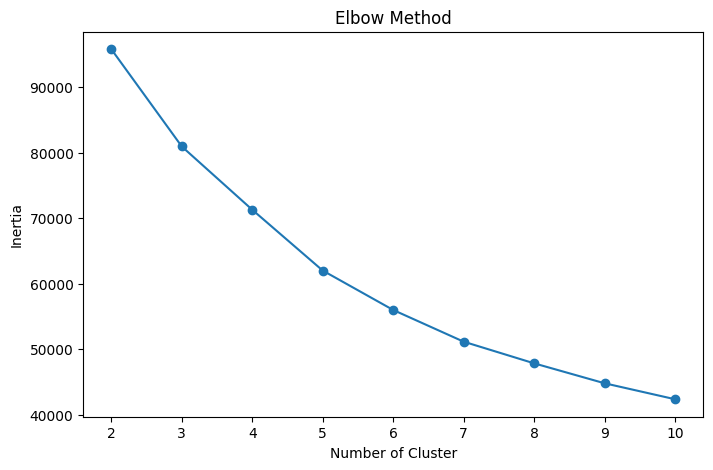

In [112]:
plt.figure(figsize=(8,5))
plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Cluster")
plt.ylabel("Inertia")
plt.title(
    "Elbow Method"
)
plt.show()

In [113]:
kmeans = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE,
    n_init=20
)

df_engineered["machine_cluster"] = (
    kmeans.fit_predict(
        cluster_scaled
    )
)
df_engineered[
    "machine_cluster"
].value_counts()

machine_cluster
1    3264
0    3051
2    2474
3    1211
Name: count, dtype: int64

In [114]:
cluster_summary = (
    df_engineered
    .groupby(
        "machine_cluster"
    )

    [
        [
            "Machine failure","anomaly_score","Tool wear [min]",
            "Torque [Nm]","machine_stress_index"
        ]
    ]
    .mean()
)
display(
    cluster_summary
)

,Machine failure,anomaly_score,Tool wear [min],Torque [Nm],machine_stress_index
machine_cluster,,,,,
0,0.045887,-0.451637,111.611603,41.588102,1.730361
1,0.002757,-0.444176,72.166667,38.944455,1.673660
2,0.062247,-0.466488,166.990703,46.494099,2.134242
3,0.029727,-0.521475,74.563171,25.468786,1.428382


In [115]:
cluster_ranking = (
    cluster_summary
    .sort_values(
        by="Machine failure",
        ascending=False
    )
)
display(
    cluster_ranking
)

,Machine failure,anomaly_score,Tool wear [min],Torque [Nm],machine_stress_index
machine_cluster,,,,,
2,0.062247,-0.466488,166.990703,46.494099,2.134242
0,0.045887,-0.451637,111.611603,41.588102,1.730361
3,0.029727,-0.521475,74.563171,25.468786,1.428382
1,0.002757,-0.444176,72.166667,38.944455,1.673660


In [116]:
cluster_labels = {}
risk_names = [
    "Healthy","Warning","High Risk","Critical"
]

for idx, cluster in enumerate(
    cluster_ranking.index[::-1]
):
    cluster_labels[
        cluster
    ] = risk_names[idx]

cluster_labels

{1: 'Healthy', 3: 'Warning', 0: 'High Risk', 2: 'Critical'}

In [117]:
df_engineered[
    "machine_segment"
] = (
    df_engineered[
        "machine_cluster"
    ]
    .map(cluster_labels)
)
df_engineered[
    "machine_segment"
].value_counts()

machine_segment
Healthy      3264
High Risk    3051
Critical     2474
Warning      1211
Name: count, dtype: int64

In [118]:
segment_report = (
    df_engineered
    .groupby(
        "machine_segment"
    )
    .agg(
        machines=(
            "machine_segment",
            "count"
        ),
        failures=(
            "Machine failure",
            "sum"
        ),
        avg_anomaly_score=(
            "anomaly_score",
            "mean"
        )
    )
)

display(
    segment_report
)

,machines,failures,avg_anomaly_score
machine_segment,,,
Critical,2474,154,-0.466488
Healthy,3264,9,-0.444176
High Risk,3051,140,-0.451637
Warning,1211,36,-0.521475


In [119]:
failure_probabilities=(
    optimized_xgb.predict_proba(X)
)[:,1]

df_engineered["failure_probability"]=failure_probabilities

df_engineered[["failure_probability"]].head()

,failure_probability
0,0.009575
1,0.011178
2,0.011060
3,0.011880
4,0.011261


In [120]:
from sklearn.preprocessing import MinMaxScaler
anomaly_normalizer=MinMaxScaler()

df_engineered["normalized_anomaly_score"]=(
    anomaly_normalizer.fit_transform(
        df_engineered[["anomaly_score"]]
    )
)

df_engineered["normalized_anomaly_score"].describe()

count    10000.000000
mean         0.764248
std          0.156136
min          0.000000
25%          0.678062
50%          0.800677
75%          0.881357
max          1.000000
Name: normalized_anomaly_score, dtype: float64

In [121]:
segment_failure_rates=(df_engineered.groupby("machine_segment")
    ["Machine failure"].mean())

segment_risk=(segment_failure_rates/segment_failure_rates.max())

segment_risk=(segment_risk.to_dict())

print("="*60)
print("Segment Risk Scores")
print("="*60)
print(segment_risk)
df_engineered["segment_risk"]=(
    df_engineered["machine_segment"].map(segment_risk)
)
display(df_engineered[["machine_segment","segment_risk"]].head())

Segment Risk Scores
{'Critical': 1.0, 'Healthy': 0.04429669595110772, 'High Risk': 0.737165161943923, 'Warning': 0.4775703239782513}


,machine_segment,segment_risk
0,Warning,0.477570
1,Healthy,0.044297
2,Healthy,0.044297
3,Healthy,0.044297
4,Healthy,0.044297


In [122]:
df_engineered["health_score"]=(
    100-(50*df_engineered["failure_probability"]+25*df_engineered["normalized_anomaly_score"]
         +25*df_engineered["segment_risk"]))
df_engineered["health_score"]=(df_engineered["health_score"].clip(lower=0,upper=100))

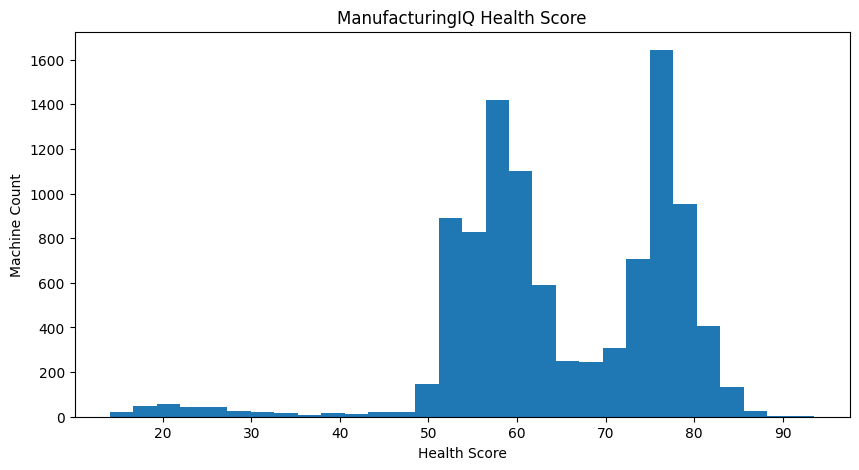

In [123]:
plt.figure(figsize=(10,5))
plt.hist(df_engineered["health_score"],bins=30)
plt.title("ManufacturingIQ Health Score")
plt.xlabel("Health Score")
plt.ylabel("Machine Count")
plt.show()

In [124]:
df_engineered["health_tier"]=pd.cut(df_engineered["health_score"],
            bins=[0,25,50,75,100],
            labels=["Critical","High Risk","Warning","Healthy"]
                                   )
df_engineered["health_tier"].value_counts()

health_tier
Warning      6450
Healthy      3172
High Risk     199
Critical      179
Name: count, dtype: int64

In [125]:
dashboard={
    "total_machines":len(df_engineered),
    "average_health_score":round(df_engineered["health_score"].mean(),2),
    "critical":int((df_engineered["health_tier"]=="Critical").sum()),
    "high_risk":int((df_engineered["health_tier"]=="High Risk").sum()),
    "warning":int((df_engineered["health_tier"]=="Warning").sum()),
    "healthy":int((df_engineered["health_tier"]=="Healthy").sum())
}
dashboard

{'total_machines': 10000,
 'average_health_score': np.float64(64.99),
 'critical': 179,
 'high_risk': 199,
 'warning': 6450,
 'healthy': 3172}

In [126]:
worst_machines=(df_engineered.sort_values(by="health_score").head(20))
display(worst_machines[["Type","Machine failure","failure_probability","health_score",
                       "health_tier","machine_segment"
                      ]
        ]
       )

,Type,Machine failure,failure_probability,health_score,health_tier,machine_segment
3019,L,1,0.905295,14.033374,Critical,Critical
6255,L,1,0.919656,14.729889,Critical,Critical
9654,L,1,0.925167,15.088687,Critical,Critical
2494,L,1,0.901235,15.146293,Critical,Critical
9653,L,1,0.904280,15.429350,Critical,Critical
1419,L,1,0.921271,15.469491,Critical,Critical
5734,L,1,0.935910,15.585200,Critical,Critical
4151,M,1,0.916448,15.792627,Critical,High Risk
2331,L,1,0.907844,15.901987,Critical,Critical
6673,L,1,0.883226,16.239148,Critical,Critical


In [127]:
validation_table=(df_engineered.groupby("Machine failure")["health_score"].mean())
display(validation_table)

Machine failure
0    66.276022
1    28.312749
Name: health_score, dtype: float64

In [128]:
print("="*80)
print("MANUFACTURINGIQ EXECUTIVE HEALTH REPORT")
print("="*80)
for key,value in dashboard.items():
    print(f"{key:<25}:{value}")

MANUFACTURINGIQ EXECUTIVE HEALTH REPORT
total_machines           :10000
average_health_score     :64.99
critical                 :179
high_risk                :199
healthy                  :3172


In [129]:
reference_data = X_train.copy()
print("="*60)
print("Reference Dataset Created")
print("="*60)
print(reference_data.shape)

Reference Dataset Created
(8000, 12)


In [130]:
production_data=X_test.copy()
production_data["Torque [Nm]"]=(
    production_data["Torque [Nm]"]*1.15)
production_data["Tool wear [min]"]=(
    production_data["Tool wear [min]"]*1.10)
production_data.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index
2997,L,300.5,309.8,1345,72.105,168.3,9.3,0.046617,9593.1,2.191876,1.030948,8.733766
4871,L,303.7,312.4,1513,46.115,148.5,8.7,0.026504,5413.5,1.776104,1.028647,11.125000
3858,L,302.5,311.4,1559,43.240,229.9,8.9,0.024118,7858.4,2.052486,1.029421,7.423810
951,H,295.6,306.3,1509,41.170,66.0,10.7,0.023724,2148.0,1.588815,1.036198,24.737705
6463,H,300.5,310.0,1358,69.460,112.2,9.5,0.044477,6160.8,1.976798,1.031614,13.184466


In [131]:
def calculate_drift(reference,current,columns):
    drift_results = []
    for column in columns:
        reference_mean=reference[column].mean()
        current_mean=current[column].mean()
        drift_percentage=(
            abs(current_mean-reference_mean)/
            (abs(reference_mean)+ 1e-6))*100
        drift_results.append({
            "feature":
                column,
            "reference_mean":
                round(reference_mean,4),
            "current_mean":
                round(current_mean,4),
            "drift_percent":
                round(drift_percentage,4)})
    return pd.DataFrame(
        drift_results
    )

In [132]:
drift_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "temperature_difference",
    "torque_speed_ratio",
    "wear_intensity",
    "machine_stress_index",
    "thermal_risk_index",
    "wear_efficiency_index"
]

print("="*60)
print("Drift Features")
print("="*60) 
print(
    f"Total Features : {len(drift_features)}"
)
for feature in drift_features:
    print(feature)

Drift Features
Total Features : 11
Air temperature [K]
Process temperature [K]
Rotational speed [rpm]
Torque [Nm]
Tool wear [min]
temperature_difference
torque_speed_ratio
wear_intensity
machine_stress_index
thermal_risk_index
wear_efficiency_index


In [133]:
drift_report=calculate_drift(
    reference_data,production_data,drift_features)
drift_report=(drift_report.sort_values(by="drift_percent",ascending=False))
display(drift_report)

,feature,reference_mean,current_mean,drift_percent
3,Torque [Nm],40.0034,45.9093,14.7635
4,Tool wear [min],107.6850,119.9165,11.3586
10,wear_efficiency_index,50.1837,52.4959,4.6074
7,wear_intensity,4302.6842,4362.5862,1.3922
8,machine_stress_index,1.7744,1.7786,0.2362
6,torque_speed_ratio,0.0269,0.0268,0.2306
2,Rotational speed [rpm],1539.3569,1536.4530,0.1886
5,temperature_difference,10.0006,10.0007,0.0009
0,Air temperature [K],300.0054,300.0028,0.0009
1,Process temperature [K],310.0061,310.0035,0.0008


In [134]:
drift_report=(drift_report.sort_values(by="drift_percent",ascending=False))
display(drift_report)

,feature,reference_mean,current_mean,drift_percent
3,Torque [Nm],40.0034,45.9093,14.7635
4,Tool wear [min],107.6850,119.9165,11.3586
10,wear_efficiency_index,50.1837,52.4959,4.6074
7,wear_intensity,4302.6842,4362.5862,1.3922
8,machine_stress_index,1.7744,1.7786,0.2362
6,torque_speed_ratio,0.0269,0.0268,0.2306
2,Rotational speed [rpm],1539.3569,1536.4530,0.1886
5,temperature_difference,10.0006,10.0007,0.0009
0,Air temperature [K],300.0054,300.0028,0.0009
1,Process temperature [K],310.0061,310.0035,0.0008


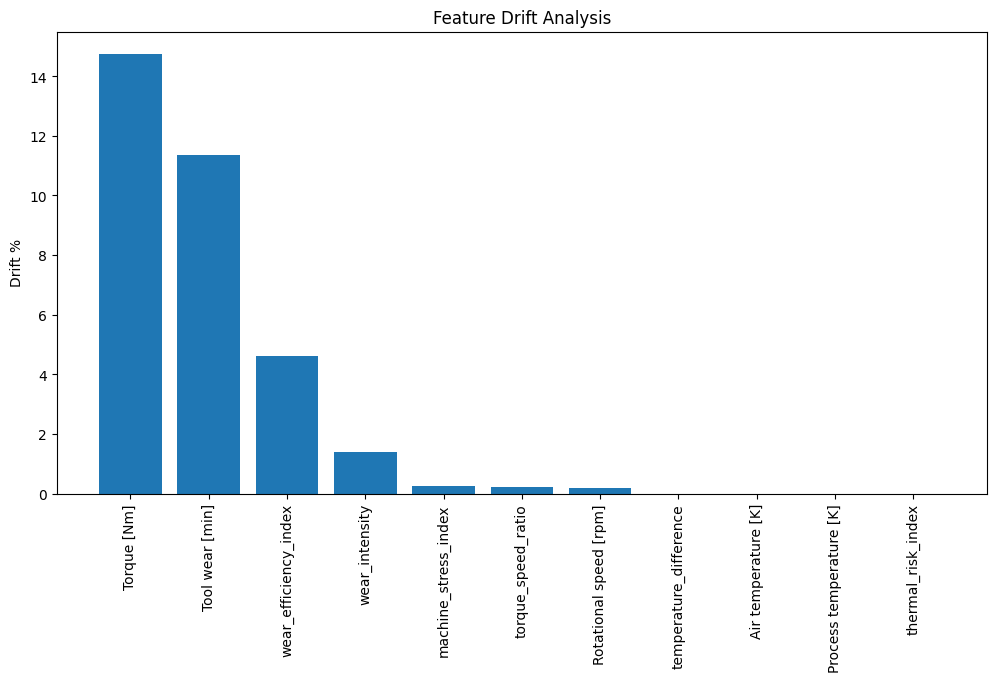

In [135]:
plt.figure(figsize=(12,6))
plt.bar(drift_report["feature"],drift_report["drift_percent"])
plt.xticks(rotation=90)
plt.ylabel("Drift %")
plt.title("Feature Drift Analysis")
plt.show()

In [136]:
DRIFT_THRESHOLD=10
drift_report["drift_detected"]=(
    drift_report["drift_percent"]
    >DRIFT_THRESHOLD)
display(drift_report)

,feature,reference_mean,current_mean,drift_percent,drift_detected
3,Torque [Nm],40.0034,45.9093,14.7635,True
4,Tool wear [min],107.6850,119.9165,11.3586,True
10,wear_efficiency_index,50.1837,52.4959,4.6074,False
7,wear_intensity,4302.6842,4362.5862,1.3922,False
8,machine_stress_index,1.7744,1.7786,0.2362,False
6,torque_speed_ratio,0.0269,0.0268,0.2306,False
2,Rotational speed [rpm],1539.3569,1536.4530,0.1886,False
5,temperature_difference,10.0006,10.0007,0.0009,False
0,Air temperature [K],300.0054,300.0028,0.0009,False
1,Process temperature [K],310.0061,310.0035,0.0008,False


In [137]:
retraining_required=bool(
    drift_report["drift_detected"].sum()>0)
print("="*60)
print(f"Retraining Required:"f"{retraining_required}")
print("="*60)

Retraining Required:True


In [138]:
drift_dashboard={
    "features_checked":
    len(drift_report),
    "drifted_features":
    int(drift_report["drift_detected"].sum()),
    "max_drift":round(drift_report["drift_percent"].max(),2),
    "retraining_required":retraining_required}
drift_dashboard

{'features_checked': 11,
 'drifted_features': 2,
 'max_drift': 14.76,
 'retraining_required': True}

In [139]:
print("="*80)
print(
    "MANUFACTURINGIQ DRIFT REPORT"
)
print("="*80)
for key, value in drift_dashboard.items():
    print(
        f"{key:<25}: {value}"
    )

MANUFACTURINGIQ DRIFT REPORT
features_checked         : 11
drifted_features         : 2
max_drift                : 14.76
retraining_required      : True


In [140]:
from datetime import datetime
current_model_version = "v1.0.0"
candidate_model_version = ("v"+
    datetime.now().strftime("%Y%m%d_%H%M%S")
)
print("="*60)
print(f"Current Version:"f"{current_model_version}"
)
print(f"Candidate Version:"f"{candidate_model_version}"
)
print("="*60)

Current Version:v1.0.0
Candidate Version:v20260713_105641


In [141]:
X_retrain = pd.concat([X_train,production_data],axis=0)
y_retrain = pd.concat([y_train,y_test],
    axis=0
)
print("="*60)
print("Retraining Dataset")
print("="*60)
print(X_retrain.shape)
print(y_retrain.shape)

Retraining Dataset
(10000, 12)
(10000,)


In [142]:
def retrain_candidate_model():
    candidate_pipeline = Pipeline(
        steps=[("preprocessing",preprocessor),
            ("classifier",XGBClassifier(**study.best_params,
                random_state=RANDOM_STATE,eval_metric="logloss"
                )
            )
        ]
    )
    candidate_pipeline.fit(X_retrain,y_retrain)
    return candidate_pipeline

In [143]:
candidate_model = (
    retrain_candidate_model()
)
print("="*60)
print("Candidate Model Trained"
)
print("="*60)

Candidate Model Trained


In [144]:
candidate_predictions=(candidate_model.predict(X_test)
)

candidate_probabilities=(candidate_model.predict_proba(X_test))[:,1]
candidate_auc=roc_auc_score(y_test,candidate_probabilities
)
candidate_f1=f1_score(y_test,candidate_predictions
)
candidate_precision=precision_score(y_test,candidate_predictions
)
candidate_recall=recall_score(y_test,candidate_predictions
)
candidate_metrics={
    "ROC_AUC":candidate_auc,
    "F1":candidate_f1,
    "Precision":candidate_precision,
    "Recall":candidate_recall
}

candidate_metrics

{'ROC_AUC': np.float64(0.9970542564852027),
 'F1': 0.9076923076923077,
 'Precision': 0.9516129032258065,
 'Recall': 0.8676470588235294}

In [145]:
production_metrics = {

    "ROC_AUC":optimized_metrics["ROC AUC"],
    "F1":optimized_metrics["F1"],
    "Precision":optimized_metrics["Precision"],
    "Recall":optimized_metrics["Recall"]
}
production_metrics

{'ROC_AUC': np.float64(0.9811609426379247),
 'F1': 0.84375,
 'Precision': 0.9,
 'Recall': 0.7941176470588235}

In [146]:
comparison_df = pd.DataFrame({
    "Metric":
        list(production_metrics.keys()
        ),
    "Production":
        list(production_metrics.values()
        ),
    "Candidate":
        list(candidate_metrics.values()
        )
})
comparison_df[
    "Difference"
] = (
    comparison_df["Candidate"]-comparison_df["Production"
    ]
)

display(
    comparison_df
)

,Metric,Production,Candidate,Difference
0,ROC_AUC,0.981161,0.997054,0.015893
1,F1,0.843750,0.907692,0.063942
2,Precision,0.900000,0.951613,0.051613
3,Recall,0.794118,0.867647,0.073529


In [147]:
candidate_better = (candidate_auc>production_metrics["ROC_AUC"
    ]
)

print("="*60)
print(
    f"Promote Candidate : "
    f"{candidate_better}"
)

print("="*60)

Promote Candidate : True


In [148]:
candidate_registry = {
    "version":candidate_model_version,
    "created_at":
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"
        ),
    "roc_auc":
        round(candidate_auc,4
        ),

    "f1_score":
        round(candidate_f1,4
        ),
    "promotion_status":
        "Production"
        if candidate_better
        else
        "Rejected"
}
candidate_registry

{'version': 'v20260713_105641',
 'created_at': '2026-07-13 10:56:43',
 'roc_auc': np.float64(0.9971),
 'f1_score': 0.9077,
 'promotion_status': 'Production'}

In [149]:
registry_history = pd.DataFrame([
    {
        "version":
            "v1.0.0",
        "roc_auc":
            production_metrics[
                "ROC_AUC"
            ],

        "status":
            "Current Production"
    },

    {

        "version":
            candidate_registry[
                "version"
            ],

        "roc_auc":
            candidate_registry[
                "roc_auc"
            ],

        "status":
            candidate_registry[
                "promotion_status"
            ]
    }
])

display(
    registry_history
)

,version,roc_auc,status
0,v1.0.0,0.981161,Current Production
1,v20260713_105641,0.997100,Production


In [150]:
print("="*80)

print(
    "MANUFACTURINGIQ RETRAINING REPORT"
)

print("="*80)

print(
    f"Drift Detected      : "
    f"{retraining_required}"
)

print(
    f"Current Version     : "
    f"{current_model_version}"
)

print(
    f"Candidate Version   : "
    f"{candidate_model_version}"
)

print(
    f"Candidate ROC-AUC   : "
    f"{candidate_auc:.4f}"
)

print(
    f"Promotion Decision  : "
    f"{candidate_better}"
)

print("="*80)

MANUFACTURINGIQ RETRAINING REPORT
Drift Detected      : True
Current Version     : v1.0.0
Candidate Version   : v20260713_105641
Candidate ROC-AUC   : 0.9971
Promotion Decision  : True


In [151]:
import mlflow
import mlflow.xgboost
print(f"MLflow version:{mlflow.__version__}")

mlflow.set_tracking_uri("sqlite:///mlflow.db")
print(mlflow.get_tracking_uri())

MLflow version:3.14.0
sqlite:///mlflow.db


In [152]:
experiment_name=("ManufacturingIQ")
mlflow.set_experiment(experiment_name)
print(f"Experiment:{experiment_name}")

2026/07/13 10:56:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/13 10:56:47 INFO mlflow.store.db.utils: Updating database tables
2026/07/13 10:56:50 INFO mlflow.tracking.fluent: Experiment with name 'ManufacturingIQ' does not exist. Creating a new experiment.


Experiment:ManufacturingIQ


In [153]:
with mlflow.start_run(run_name="Production_Model"
):
    mlflow.log_param("model_type","Optimized_XGBoost"
    )

    mlflow.log_param("version",current_model_version
    )

    mlflow.log_metric("roc_auc",production_metrics["ROC_AUC"]
    )

    mlflow.log_metric("f1_score",production_metrics["F1"]
    )

    mlflow.log_metric("precision",production_metrics["Precision"]
    )

    mlflow.log_metric("recall",production_metrics["Recall"]
    )

print(
    "Production Model Logged"
)

Production Model Logged


In [154]:
with mlflow.start_run(run_name="Candidate_Model"
):
    mlflow.log_param("model_type","Retrained_XGBoost"
    )
    mlflow.log_param("version",candidate_model_version
    )
    mlflow.log_metric("roc_auc",candidate_auc
    )
    mlflow.log_metric("f1_score",candidate_f1
    )
    mlflow.log_metric("precision",candidate_precision
    )
    mlflow.log_metric("recall",candidate_recall
    )
    
    
print("Candidate Model Logged"
)

Candidate Model Logged


In [155]:
experiment = mlflow.get_experiment_by_name("ManufacturingIQ"
)
print(experiment
)

<Experiment: artifact_location='/kaggle/working/mlruns/1', creation_time=1783940210080, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783940210080, lifecycle_stage='active', name='ManufacturingIQ', tags={}, trace_location=None, workspace='default'>


In [156]:
runs=mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)
runs.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.precision,metrics.roc_auc,metrics.f1_score,metrics.recall,params.model_type,params.version,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.user
0,1bb3ad92baa448debb35d3592243e48d,1,FINISHED,/kaggle/working/mlruns/1/1bb3ad92baa448debb35d...,2026-07-13 10:56:50.626000+00:00,2026-07-13 10:56:50.691000+00:00,0.951613,0.997054,0.907692,0.867647,Retrained_XGBoost,v20260713_105641,/usr/local/lib/python3.12/dist-packages/colab_...,NOTEBOOK,Candidate_Model,root
1,1d6e6e0cc16742a99e0c1ca3cd02d08f,1,FINISHED,/kaggle/working/mlruns/1/1d6e6e0cc16742a99e0c1...,2026-07-13 10:56:50.443000+00:00,2026-07-13 10:56:50.520000+00:00,0.900000,0.981161,0.843750,0.794118,Optimized_XGBoost,v1.0.0,/usr/local/lib/python3.12/dist-packages/colab_...,NOTEBOOK,Production_Model,root


In [157]:
runs[["tags.mlflow.runName","metrics.roc_auc","metrics.f1_score","metrics.precision","metrics.recall"
    ]
]

,tags.mlflow.runName,metrics.roc_auc,metrics.f1_score,metrics.precision,metrics.recall
0,Candidate_Model,0.997054,0.907692,0.951613,0.867647
1,Production_Model,0.981161,0.843750,0.900000,0.794118


In [158]:
best_run = (runs.sort_values(
        by="metrics.roc_auc",
        ascending=False
    ).head(1)
)
display(
    best_run
)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.precision,metrics.roc_auc,metrics.f1_score,metrics.recall,params.model_type,params.version,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.user
0,1bb3ad92baa448debb35d3592243e48d,1,FINISHED,/kaggle/working/mlruns/1/1bb3ad92baa448debb35d...,2026-07-13 10:56:50.626000+00:00,2026-07-13 10:56:50.691000+00:00,0.951613,0.997054,0.907692,0.867647,Retrained_XGBoost,v20260713_105641,/usr/local/lib/python3.12/dist-packages/colab_...,NOTEBOOK,Candidate_Model,root


In [159]:
tracking_dashboard = {"experiment":experiment_name,
    "total_runs":len(runs),
    "best_roc_auc":
        runs["metrics.roc_auc"].max(),
    "candidate_version":candidate_model_version,
    "production_version":current_model_version
}
tracking_dashboard

{'experiment': 'ManufacturingIQ',
 'total_runs': 2,
 'best_roc_auc': 0.9970542564852027,
 'candidate_version': 'v20260713_105641',
 'production_version': 'v1.0.0'}

In [160]:
print("="*80)
print(
    "MANUFACTURINGIQ MLFLOW REPORT"
)
print("="*80)
for key, value in tracking_dashboard.items():
    print(
        f"{key:<25}: {value}"
    )

MANUFACTURINGIQ MLFLOW REPORT
experiment               : ManufacturingIQ
total_runs               : 2
best_roc_auc             : 0.9970542564852027
candidate_version        : v20260713_105641
production_version       : v1.0.0


In [161]:
production_predictions = candidate_model.predict(X_test
)
production_probabilities = (candidate_model.predict_proba(X_test)[:,1]
)

monitoring_df = X_test.copy()

monitoring_df["predicted_failure"] = (production_predictions
)
monitoring_df["failure_probability"] = (production_probabilities
)
monitoring_df["actual_failure"] = (y_test.values
)
print("="*70)
print("PRODUCTION MONITORING DATASET")
print("="*70)
print(monitoring_df.shape)

display(
    monitoring_df.head()
)

PRODUCTION MONITORING DATASET
(2000, 15)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index,predicted_failure,failure_probability,actual_failure
2997,L,300.5,309.8,1345,62.7,153,9.3,0.046617,9593.1,2.191876,1.030948,8.733766,0,0.053570,0
4871,L,303.7,312.4,1513,40.1,135,8.7,0.026504,5413.5,1.776104,1.028647,11.125000,0,0.009558,0
3858,L,302.5,311.4,1559,37.6,209,8.9,0.024118,7858.4,2.052486,1.029421,7.423810,0,0.125532,0
951,H,295.6,306.3,1509,35.8,60,10.7,0.023724,2148.0,1.588815,1.036198,24.737705,0,0.010017,0
6463,H,300.5,310.0,1358,60.4,102,9.5,0.044477,6160.8,1.976798,1.031614,13.184466,0,0.031655,0


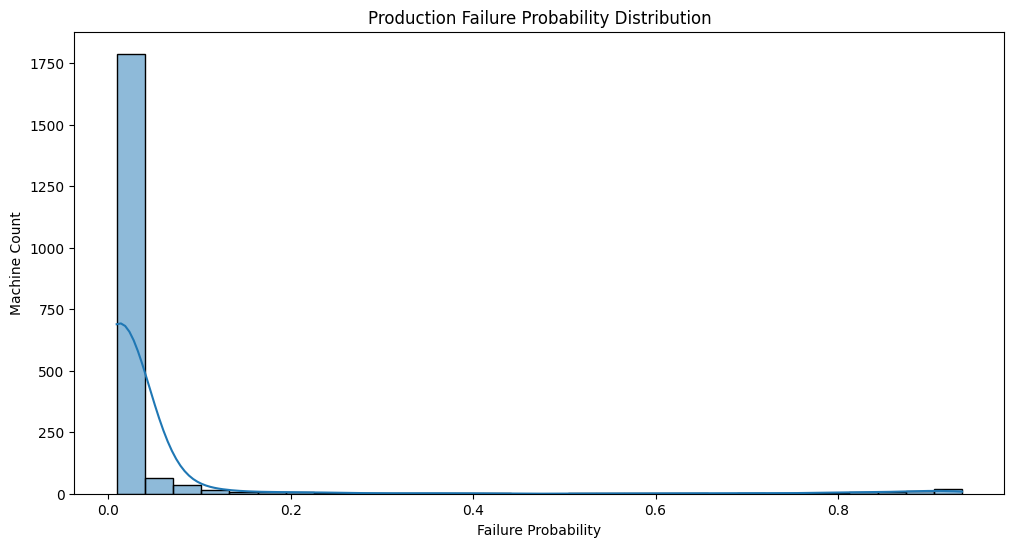

In [162]:
plt.figure(figsize=(12,6))
sns.histplot(
    monitoring_df["failure_probability"],
    bins=30,
    kde=True
)
plt.title(
    "Production Failure Probability Distribution"
)
plt.xlabel(
    "Failure Probability"
)
plt.ylabel(
    "Machine Count"
)
plt.show()

In [163]:
high_risk_machines = monitoring_df[monitoring_df["failure_probability"] >= 0.80
]
print("="*70)
print("HIGH RISK MACHINES")
print("="*70)
print(f"Total High Risk Machines : "f"{len(high_risk_machines)}"
)
display(
    high_risk_machines.head(10)
)

HIGH RISK MACHINES
Total High Risk Machines : 46


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index,predicted_failure,failure_probability,actual_failure
4851,L,303.7,312.1,1363,51.8,90,8.4,0.038004,4662.0,1.726186,1.027659,14.978022,1,0.824265,1
1391,L,298.9,310.2,2737,8.8,142,11.3,0.003215,1249.6,1.610032,1.037805,19.139860,1,0.897805,1
4495,L,302.6,310.4,1359,57.2,67,7.8,0.042090,3832.4,1.656187,1.025777,19.985294,1,0.897092,1
8582,M,297.5,308.1,1334,72.0,151,10.6,0.053973,10872.0,2.412819,1.035630,8.776316,1,0.815913,1
9664,L,299.1,310.2,1317,54.8,231,11.1,0.041610,12658.8,2.545804,1.037111,5.676724,1,0.904936,1
4632,M,302.9,311.2,1330,53.7,200,8.3,0.040376,10740.0,2.177509,1.027402,6.616915,1,0.847105,1
2444,L,299.2,308.6,1267,68.2,76,9.4,0.053828,5183.2,1.967594,1.031417,16.454545,1,0.807154,1
926,L,295.6,306.1,1372,55.6,215,10.5,0.040525,11954.0,2.443420,1.035521,6.351852,1,0.908850,1
3814,M,302.1,310.6,1326,59.1,88,8.5,0.044570,5200.8,1.821846,1.028136,14.898876,1,0.917829,1
4270,L,302.6,310.9,1331,52.0,154,8.3,0.039068,8008.0,1.973497,1.027429,8.587097,1,0.927217,1


In [164]:
probability_dashboard = {"average_probability":round(monitoring_df["failure_probability"].mean(),4),

    "maximum_probability":
        round(monitoring_df["failure_probability"].max(),4
        ),

    "minimum_probability":
        round(
            monitoring_df[
                "failure_probability"
            ].min(),
            4
        ),

    "high_risk_machines":
        len(
            high_risk_machines
        )
}

probability_dashboard

{'average_probability': np.float32(0.0449),
 'maximum_probability': 0.9361,
 'minimum_probability': 0.0093,
 'high_risk_machines': 46}

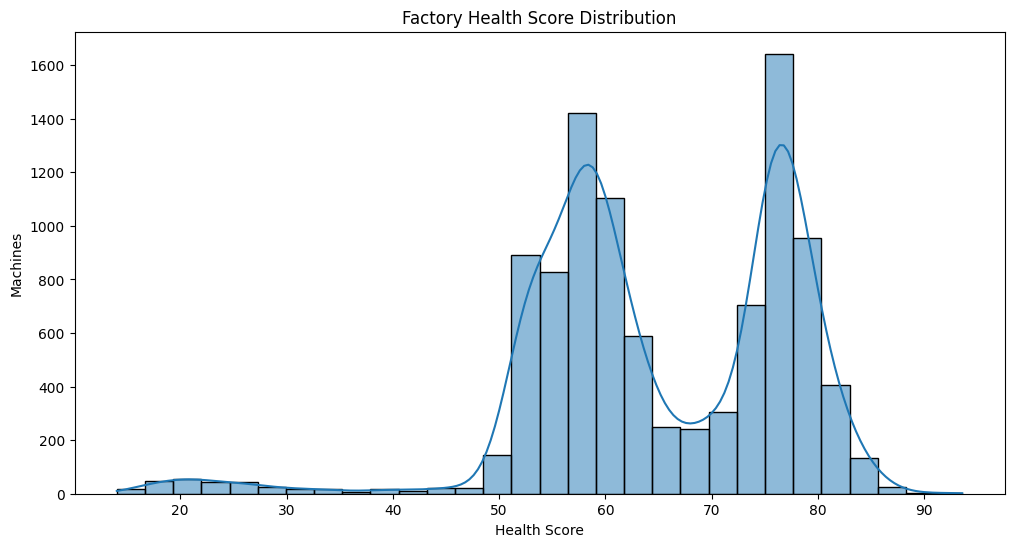

In [165]:
plt.figure(figsize=(12,6))
sns.histplot(
    df_engineered["health_score"],bins=30,kde=True
)
plt.title("Factory Health Score Distribution"
)
plt.xlabel("Health Score"
)

plt.ylabel("Machines"
)

plt.show()

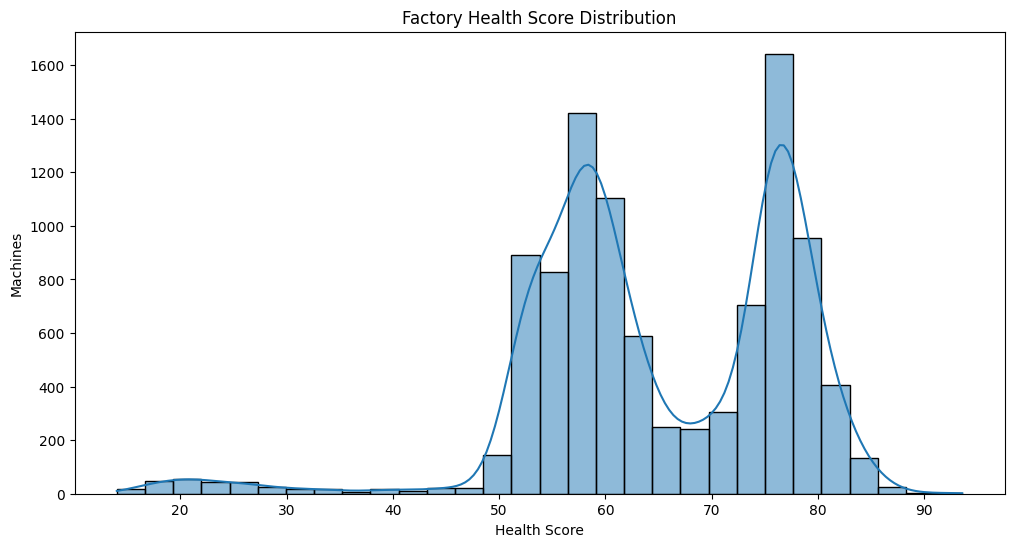

In [166]:
plt.figure(figsize=(12,6))
sns.histplot(
    df_engineered["health_score"],bins=30,kde=True
)
plt.title("Factory Health Score Distribution"
)
plt.xlabel("Health Score"
)
plt.ylabel("Machines"
)
plt.show()

In [167]:
health_dashboard = {

    "average_health":
        round(
            df_engineered[
                "health_score"
            ].mean(),
            2
        ),

    "minimum_health":
        round(
            df_engineered[
                "health_score"
            ].min(),
            2
        ),

    "maximum_health":
        round(
            df_engineered[
                "health_score"
            ].max(),
            2
        ),

    "critical_machines":
        int(
            (
                df_engineered[
                    "health_score"
                ] < 20
            ).sum()
        )
}

health_dashboard

{'average_health': np.float64(64.99),
 'minimum_health': 14.03,
 'maximum_health': 93.57,
 'critical_machines': 79}

In [168]:
segment_distribution = (

    df_engineered[
        "machine_segment"
    ]

    .value_counts()

    .reset_index()
)

segment_distribution.columns = [

    "segment",
    "machine_count"
]

display(
    segment_distribution
)

,segment,machine_count
0,Healthy,3264
1,High Risk,3051
2,Critical,2474
3,Warning,1211


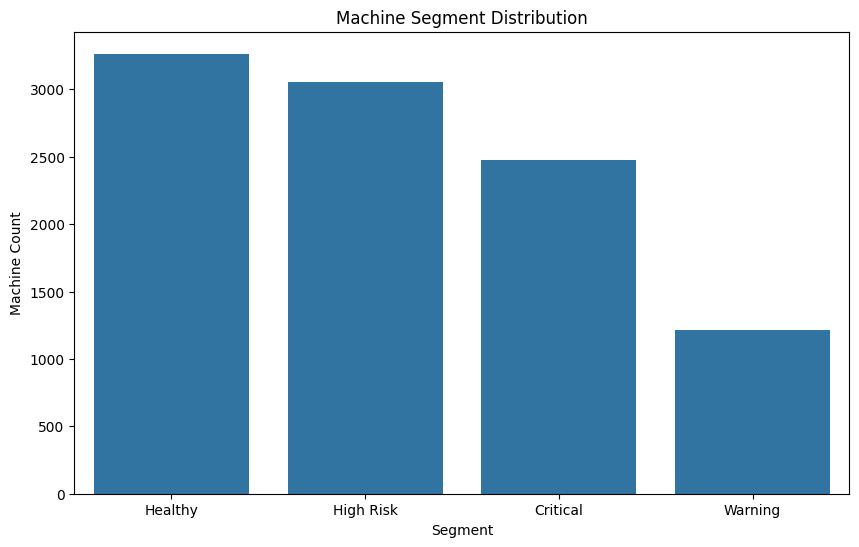

In [169]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=segment_distribution,

    x="segment",

    y="machine_count"
)

plt.title(
    "Machine Segment Distribution"
)

plt.xlabel(
    "Segment"
)

plt.ylabel(
    "Machine Count"
)

plt.show()

In [170]:
factory_failure_rate = (

    df_engineered[
        "Machine failure"
    ]

    .mean()

    *100
)

print("="*70)
print("FACTORY FAILURE RATE")
print("="*70)

print(
    f"Failure Rate : "
    f"{factory_failure_rate:.2f}%"
)

FACTORY FAILURE RATE
Failure Rate : 3.39%


In [171]:
alerts = []

if factory_failure_rate > 5:

    alerts.append(
        "Factory Failure Rate Above Threshold"
    )

if len(high_risk_machines) > 100:

    alerts.append(
        "Large Number Of High Risk Machines"
    )

if health_dashboard[
    "average_health"
] < 50:

    alerts.append(
        "Factory Health Deteriorating"
    )

if drift_dashboard[
    "retraining_required"
]:

    alerts.append(
        "Model Drift Detected"
    )

alerts

['Model Drift Detected']

In [172]:
executive_dashboard = {

    "total_machines":
        len(df_engineered),

    "average_health":
        health_dashboard[
            "average_health"
        ],

    "failure_rate":
        round(
            factory_failure_rate,
            2
        ),

    "high_risk_machines":
        len(
            high_risk_machines
        ),

    "critical_machines":
        health_dashboard[
            "critical_machines"
        ],

    "active_alerts":
        len(
            alerts
        )
}

executive_dashboard

{'total_machines': 10000,
 'average_health': np.float64(64.99),
 'failure_rate': np.float64(3.39),
 'high_risk_machines': 46,
 'critical_machines': 79,
 'active_alerts': 1}

In [173]:
print("="*90)
print("MANUFACTURINGIQ LIVE MONITORING REPORT")
print("="*90)

for key,value in executive_dashboard.items():

    print(
        f"{key:<30}:{value}"
    )

print("\n")

print("="*90)
print("ACTIVE ALERTS")
print("="*90)

if len(alerts)==0:

    print(
        "No Active Alerts"
    )

else:

    for alert in alerts:

        print(
            f"⚠ {alert}"
        )

MANUFACTURINGIQ LIVE MONITORING REPORT
total_machines                :10000
average_health                :64.99
failure_rate                  :3.39
high_risk_machines            :46
critical_machines             :79
active_alerts                 :1


ACTIVE ALERTS
⚠ Model Drift Detected


In [174]:
with mlflow.start_run(

    run_name="Factory_Monitoring"

):

    mlflow.log_metric(
        "factory_failure_rate",
        factory_failure_rate
    )

    mlflow.log_metric(
        "average_health",
        health_dashboard[
            "average_health"
        ]
    )

    mlflow.log_metric(
        "high_risk_machines",
        len(high_risk_machines)
    )

    mlflow.log_metric(
        "critical_machines",
        health_dashboard[
            "critical_machines"
        ]
    )

print(
    "Monitoring Metrics Logged"
)

Monitoring Metrics Logged


In [175]:
monitoring_summary = {

    "monitoring_enabled":
        True,

    "alerts_generated":
        len(alerts),

    "drift_monitoring":
        True,

    "health_monitoring":
        True,

    "prediction_monitoring":
        True,

    "mlflow_tracking":
        True
}

monitoring_summary

{'monitoring_enabled': True,
 'alerts_generated': 1,
 'drift_monitoring': True,
 'health_monitoring': True,
 'prediction_monitoring': True,
 'mlflow_tracking': True}

In [176]:
streaming_factory = (

    df_engineered.sample(
        100,
        random_state=42
    )

    .copy()

)

streaming_factory.reset_index(
    drop=True,
    inplace=True
)

print("="*70)
print("FACTORY STREAM CREATED")
print("="*70)

print(
    f"Machines In Stream : "
    f"{len(streaming_factory)}"
)

display(
    streaming_factory.head()
)

FACTORY STREAM CREATED
Machines In Stream : 100


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index,anomaly_score,anomaly_flag,machine_cluster,machine_segment,failure_probability,normalized_anomaly_score,segment_risk,health_score,health_tier
0,6253,L53432,L,300.8,310.3,1538,36.1,198,0,0,0,0,0,0,9.5,0.023472,7147.8,2.039012,1.031582,7.728643,-0.423427,1,0,High Risk,0.015947,0.894205,0.737165,58.418398,Warning
1,4685,M19544,M,303.6,311.8,1421,44.8,101,1,0,0,0,0,0,8.2,0.031527,4524.8,1.661752,1.027009,13.931373,-0.480427,1,0,High Risk,0.334693,0.698788,0.737165,47.366537,High Risk
2,1732,M16591,M,298.3,307.9,1485,42.0,117,0,0,0,0,0,0,9.6,0.028283,4914.0,1.804142,1.032182,12.584746,-0.415721,1,1,Healthy,0.009409,0.920623,0.044297,75.406584,Healthy
3,4743,L51922,L,303.3,311.3,1592,33.7,14,0,0,0,0,0,0,8.0,0.021168,471.8,1.156441,1.026377,106.133333,-0.543438,1,3,Warning,0.011148,0.482761,0.477570,75.434317,Healthy
4,4522,L51701,L,302.4,310.4,1865,23.9,129,0,0,0,0,0,0,8.0,0.012815,3083.1,1.483049,1.026455,14.346154,-0.518325,1,3,Warning,0.011116,0.568856,0.477570,73.283527,Warning


In [177]:
np.random.seed(42)

streaming_factory[
    "Torque [Nm]"
] *= np.random.uniform(
    0.90,
    1.20,
    len(streaming_factory)
)

streaming_factory[
    "Tool wear [min]"
] *= np.random.uniform(
    1.00,
    1.30,
    len(streaming_factory)
)

streaming_factory[
    "Rotational speed [rpm]"
] *= np.random.uniform(
    0.95,
    1.10,
    len(streaming_factory)
)

display(
    streaming_factory.head()
)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index,anomaly_score,anomaly_flag,machine_cluster,machine_segment,failure_probability,normalized_anomaly_score,segment_risk,health_score,health_tier
0,6253,L53432,L,300.8,310.3,1609.216701,36.546269,199.866894,0,0,0,0,0,0,9.5,0.023472,7147.8,2.039012,1.031582,7.728643,-0.423427,1,0,High Risk,0.015947,0.894205,0.737165,58.418398,Warning
1,4685,M19544,M,303.6,311.8,1367.884434,53.097600,120.283235,1,0,0,0,0,0,8.2,0.031527,4524.8,1.661752,1.027009,13.931373,-0.480427,1,0,High Risk,0.334693,0.698788,0.737165,47.366537,High Risk
2,1732,M16591,M,298.3,307.9,1446.752796,47.023124,128.033895,0,0,0,0,0,0,9.6,0.028283,4914.0,1.804142,1.032182,12.584746,-0.415721,1,1,Healthy,0.009409,0.920623,0.044297,75.406584,Healthy
3,4743,L51922,L,303.3,311.3,1726.974740,36.382437,16.135997,0,0,0,0,0,0,8.0,0.021168,471.8,1.156441,1.026377,106.133333,-0.543438,1,3,Warning,0.011148,0.482761,0.477570,75.434317,Healthy
4,4522,L51701,L,302.4,310.4,1941.398529,22.628654,164.122823,0,0,0,0,0,0,8.0,0.012815,3083.1,1.483049,1.026455,14.346154,-0.518325,1,3,Warning,0.011116,0.568856,0.477570,73.283527,Warning


In [178]:
streaming_factory[
    "temperature_difference"
] = (

    streaming_factory[
        "Process temperature [K]"
    ]

    -

    streaming_factory[
        "Air temperature [K]"
    ]
)

streaming_factory[
    "torque_speed_ratio"
] = (

    streaming_factory[
        "Torque [Nm]"
    ]

    /

    streaming_factory[
        "Rotational speed [rpm]"
    ]
)

streaming_factory[
    "wear_intensity"
] = (

    streaming_factory[
        "Tool wear [min]"
    ]

    *

    streaming_factory[
        "Torque [Nm]"
    ]
)

streaming_factory[
    "machine_stress_index"
] = (

    streaming_factory[
        "Torque [Nm]"
    ]

    *

    streaming_factory[
        "Rotational speed [rpm]"
    ]
)

display(
    streaming_factory.head()
)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index,anomaly_score,anomaly_flag,machine_cluster,machine_segment,failure_probability,normalized_anomaly_score,segment_risk,health_score,health_tier
0,6253,L53432,L,300.8,310.3,1609.216701,36.546269,199.866894,0,0,0,0,0,0,9.5,0.022711,7304.389356,58810.867209,1.031582,7.728643,-0.423427,1,0,High Risk,0.015947,0.894205,0.737165,58.418398,Warning
1,4685,M19544,M,303.6,311.8,1367.884434,53.097600,120.283235,1,0,0,0,0,0,8.2,0.038817,6386.751157,72631.380879,1.027009,13.931373,-0.480427,1,0,High Risk,0.334693,0.698788,0.737165,47.366537,High Risk
2,1732,M16591,M,298.3,307.9,1446.752796,47.023124,128.033895,0,0,0,0,0,0,9.6,0.032503,6020.553675,68030.835645,1.032182,12.584746,-0.415721,1,1,Healthy,0.009409,0.920623,0.044297,75.406584,Healthy
3,4743,L51922,L,303.3,311.3,1726.974740,36.382437,16.135997,0,0,0,0,0,0,8.0,0.021067,587.066895,62831.550162,1.026377,106.133333,-0.543438,1,3,Warning,0.011148,0.482761,0.477570,75.434317,Healthy
4,4522,L51701,L,302.4,310.4,1941.398529,22.628654,164.122823,0,0,0,0,0,0,8.0,0.011656,3713.878508,43931.234923,1.026455,14.346154,-0.518325,1,3,Warning,0.011116,0.568856,0.477570,73.283527,Warning


In [179]:
stream_probabilities = (

    candidate_model.predict_proba(
        streaming_factory[
            X_train.columns
        ]
    )[:,1]

)

stream_predictions = (

    candidate_model.predict(
        streaming_factory[
            X_train.columns
        ]
    )

)

streaming_factory[
    "failure_probability"
] = stream_probabilities

streaming_factory[
    "predicted_failure"
] = stream_predictions

display(
    streaming_factory[
        [
            "failure_probability",
            "predicted_failure"
        ]
    ].head()
)

,failure_probability,predicted_failure
0,0.017221,0
1,0.874318,1
2,0.019437,0
3,0.025670,0
4,0.030661,0


In [180]:
streaming_factory[
    "live_health_score"
] = (

    100

    -

    (
        streaming_factory[
            "failure_probability"
        ]

        *100
    )
)

streaming_factory[
    "live_health_score"
] = (

    streaming_factory[
        "live_health_score"
    ]

    .clip(
        lower=0,
        upper=100
    )
)

display(
    streaming_factory[
        [
            "failure_probability",
            "live_health_score"
        ]
    ].head()
)

,failure_probability,live_health_score
0,0.017221,98.277946
1,0.874318,12.568245
2,0.019437,98.056351
3,0.025670,97.433014
4,0.030661,96.933929


In [181]:
conditions = [

    streaming_factory[
        "live_health_score"
    ] < 20,

    streaming_factory[
        "live_health_score"
    ] < 50,

    streaming_factory[
        "live_health_score"
    ] < 80
]

choices = [

    "Critical",
    "High Risk",
    "Warning"
]

streaming_factory[
    "live_status"
] = np.select(
    conditions,
    choices,
    default="Healthy"
)

display(
    streaming_factory[
        [
            "live_health_score",
            "live_status"
        ]
    ].head()
)

,live_health_score,live_status
0,98.277946,Healthy
1,12.568245,Critical
2,98.056351,Healthy
3,97.433014,Healthy
4,96.933929,Healthy


In [182]:
live_alerts = streaming_factory[

    streaming_factory[
        "live_status"
    ]

    == "Critical"
]

print("="*70)
print("LIVE FACTORY ALERTS")
print("="*70)

print(
    f"Critical Machines : "
    f"{len(live_alerts)}"
)

display(
    live_alerts.head(10)
)

LIVE FACTORY ALERTS
Critical Machines : 2


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature_difference,torque_speed_ratio,wear_intensity,machine_stress_index,thermal_risk_index,wear_efficiency_index,anomaly_score,anomaly_flag,machine_cluster,machine_segment,failure_probability,normalized_anomaly_score,segment_risk,health_score,health_tier,predicted_failure,live_health_score,live_status
1,4685,M19544,M,303.6,311.8,1367.884434,53.097600,120.283235,1,0,0,0,0,0,8.2,0.038817,6386.751157,72631.380879,1.027009,13.931373,-0.480427,1,0,High Risk,0.874318,0.698788,0.737165,47.366537,High Risk,1,12.568245,Critical
16,583,L47762,L,297.8,309.7,1339.404149,48.770616,258.149138,0,0,0,0,0,0,11.9,0.036412,12590.092333,65323.564772,1.039960,6.416268,-0.563716,1,2,Critical,0.850382,0.413238,1.000000,59.118358,Warning,1,14.961761,Critical


In [183]:
live_dashboard = {

    "machines_monitored":
        len(streaming_factory),

    "critical":
        int(
            (
                streaming_factory[
                    "live_status"
                ]

                == "Critical"
            ).sum()
        ),

    "high_risk":
        int(
            (
                streaming_factory[
                    "live_status"
                ]

                == "High Risk"
            ).sum()
        ),

    "warning":
        int(
            (
                streaming_factory[
                    "live_status"
                ]

                == "Warning"
            ).sum()
        ),

    "healthy":
        int(
            (
                streaming_factory[
                    "live_status"
                ]

                == "Healthy"
            ).sum()
        )
}

live_dashboard

{'machines_monitored': 100,
 'critical': 2,
 'high_risk': 2,
 'warning': 3,
 'healthy': 93}

In [184]:
print("="*90)
print("MANUFACTURINGIQ LIVE FACTORY REPORT")
print("="*90)

for key,value in live_dashboard.items():

    print(
        f"{key:<25}:{value}"
    )

MANUFACTURINGIQ LIVE FACTORY REPORT
machines_monitored       :100
critical                 :2
high_risk                :2
healthy                  :93


In [185]:
import joblib
import os

os.makedirs(
    "models",exist_ok=True)

joblib.dump(
    candidate_model,"models/production_model.pkl"
)
print("Production model saved")

Production model saved


In [186]:
feature_columns=list(X_train.columns)
joblib.dump(feature_columns,"models/feature_columns.pkl"
           )
print("Feature Columns Saved")

Feature Columns Saved


In [187]:
model_metadata={
    "model_name":"ManufacturingIQ_XGB",
    "version":"v1.0.0",
    "roc_auc":candidate_auc,
    "feature_count":len(feature_columns)
}

In [188]:
import json
with open("models/model_metadata.json",
          "w") as f:
    json.dump(model_metadata,f,indent=4)
print("Metadata saved")

Metadata saved


In [189]:
loaded_model=joblib.load("models/production_model.pkl")
loaded_features=joblib.load("models/feature_columns.pkl")
print(type(loaded_model))
print(loaded_features[:5])

<class 'sklearn.pipeline.Pipeline'>
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']
